In [369]:
# ============================================
# CELL 1: IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, roc_auc_score, accuracy_score

import shap
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("✅ All libraries imported successfully")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")
print(f"SHAP version: {shap.__version__}")

✅ All libraries imported successfully
Pandas version: 2.3.3
NumPy version: 2.3.5
Scikit-learn version: 1.8.0
SHAP version: 0.51.0


In [370]:
# ============================================
# CELL 2: generated dataset

# ============================================

import pandas as pd
import numpy as np

np.random.seed(42)
n_students = 500

print("=" * 60)
print("GENERATING FINAL DATASET")
print("Importance order: poetry > rhetoric > grammar > prose > essay > comprehension")
print("Exam-BAC correlation target: ~0.38")
print("Mean BAC Score Target: ~13.2")
print("=" * 60)

# ============================================
# STEP 1: Generate Core BAC Skills (0-10 scale)
# FORCED: poetry and grammar have highest correlation
# ============================================

# Base skill - normal distribution, mean 6.8, std 1.8
base_skill = np.random.normal(6.8, 1.8, n_students)
base_skill = np.clip(base_skill, 2.5, 9.5)

# Generate skills with FORCED correlation order
poetry = base_skill * 0.95 + np.random.normal(0, 0.6, n_students)      # Strongest
poetry = np.clip(poetry, 2.5, 10)

rhetoric = base_skill * 0.75 + np.random.normal(0, 1.0, n_students)     # Weaker than poetry
rhetoric = np.clip(rhetoric, 2, 9.5)

grammar = base_skill * 0.90 + np.random.normal(0, 0.7, n_students)      # Second strongest
grammar = np.clip(grammar, 2.5, 10)

prose = base_skill * 0.80 + np.random.normal(0, 0.8, n_students)
prose = np.clip(prose, 2.5, 10)

essay = base_skill * 0.75 + np.random.normal(0, 0.9, n_students)
essay = np.clip(essay, 2, 10)

comprehension = base_skill * 0.75 + np.random.normal(0, 0.8, n_students)
comprehension = np.clip(comprehension, 3, 10)

# Round skills
poetry = np.round(poetry, 1)
rhetoric = np.round(rhetoric, 1)
grammar = np.round(grammar, 1)
prose = np.round(prose, 1)
essay = np.round(essay, 1)
comprehension = np.round(comprehension, 1)

print("\n📊 Step 1: Core Skills Generated (0-10 scale)")
print(f"   Poetry mean: {poetry.mean():.1f} (std: {poetry.std():.1f})")
print(f"   Rhetoric mean: {rhetoric.mean():.1f} (std: {rhetoric.std():.1f})")
print(f"   Grammar mean: {grammar.mean():.1f} (std: {grammar.std():.1f})")
print(f"   Prose mean: {prose.mean():.1f} (std: {prose.std():.1f})")
print(f"   Essay mean: {essay.mean():.1f} (std: {essay.std():.1f})")

# ============================================
# STEP 2: Generate Consistency, Participation, Study Hours
# ============================================

consistency = np.random.choice([1,2,3,4,5], n_students, p=[0.05,0.1,0.2,0.35,0.3])
participation = np.random.choice([1,2,3,4,5], n_students, p=[0.05,0.1,0.25,0.35,0.25])
study_hours = np.random.normal(5, 2, n_students)
study_hours = np.clip(study_hours, 2, 12)
study_hours = np.round(study_hours, 1)

# Scale to 0-10
consistency_scaled = (consistency / 5) * 10
participation_scaled = (participation / 5) * 10
study_hours_scaled = (study_hours / 12) * 10

print("\n📊 Step 2: Consistency, Participation, Study Hours Generated")
print(f"   Consistency mean: {consistency.mean():.1f}")
print(f"   Participation mean: {participation.mean():.1f}")
print(f"   Study hours mean: {study_hours.mean():.1f}")

# ============================================
# STEP 3: Calculate avg_grade (YOUR DESIRED ORDER)
# ============================================

# Skills weighted to achieve: poetry > rhetoric > grammar > prose > essay > comprehension
skills_score = (
    0.24 * poetry +      # 24% (highest)
    0.20 * rhetoric +    # 20%
    0.18 * grammar +     # 18%
    0.14 * prose +       # 14%
    0.12 * essay +       # 12%
    0.08 * comprehension # 8%
)

avg_grade = (
    0.60 * skills_score +
    0.15 * consistency_scaled +
    0.10 * participation_scaled +
    0.10 * study_hours_scaled
)

# Scale to target mean ~13.2
avg_grade = avg_grade * 2.2

# Add stream adjustment
filiere = np.random.choice([0, 1, 2], n_students, p=[0.5, 0.3, 0.2])
stream_boost = np.where(filiere == 2, 1.0, np.where(filiere == 0, -0.5, 0))
avg_grade = avg_grade + stream_boost

# Add moderate noise for realistic dispersion
avg_grade = avg_grade + np.random.normal(0, 0.6, n_students)

avg_grade = np.clip(avg_grade, 8, 19.5)
avg_grade = np.round(avg_grade, 1)

print(f"\n📊 Step 3: avg_grade Calculated")
print(f"   Skills breakdown: poetry 24%, rhetoric 20%, grammar 18%, prose 14%, essay 12%, comprehension 8%")
print(f"   Mean: {avg_grade.mean():.1f}")
print(f"   Min: {avg_grade.min():.1f}")
print(f"   Max: {avg_grade.max():.1f}")
print(f"   Std: {avg_grade.std():.1f}")

# ============================================
# STEP 4: Generate Trimester Grades (normal around avg_grade)
# ============================================

grade_t1 = avg_grade + np.random.normal(-0.5, 1.2, n_students)
grade_t2 = avg_grade + np.random.normal(0, 1.1, n_students)
grade_t3 = avg_grade + np.random.normal(0.5, 1.0, n_students)

grade_t1 = np.clip(grade_t1, 8, 19.5)
grade_t2 = np.clip(grade_t2, 8, 19.5)
grade_t3 = np.clip(grade_t3, 8, 19.5)

grade_t1 = np.round(grade_t1, 1)
grade_t2 = np.round(grade_t2, 1)
grade_t3 = np.round(grade_t3, 1)

print(f"\n📊 Step 4: Trimester Grades Generated")
print(f"   T1 mean: {grade_t1.mean():.1f} (std: {grade_t1.std():.1f})")
print(f"   T2 mean: {grade_t2.mean():.1f} (std: {grade_t2.std():.1f})")
print(f"   T3 mean: {grade_t3.mean():.1f} (std: {grade_t3.std():.1f})")

# ============================================
# STEP 5: Generate Exams, Essays, Psychological Factors
# ============================================

exams_practiced = np.random.poisson(5, n_students)
exams_practiced = np.clip(exams_practiced, 0, 20)
essays_per_week = np.random.choice([0,1,2,3,4,5], n_students, p=[0.05,0.1,0.3,0.3,0.15,0.1])
confidence = np.random.choice([1,2,3,4,5], n_students, p=[0.05,0.1,0.3,0.35,0.2])
stress = np.random.choice([1,2,3,4,5], n_students, p=[0.05,0.1,0.25,0.35,0.25])
tutoring = np.random.choice([0,1], n_students, p=[0.7,0.3])
interest = np.random.choice([1,2,3,4,5], n_students, p=[0.05,0.1,0.25,0.35,0.25])

# Scale to 0-10
exams_scaled = (exams_practiced / 20) * 10
essays_scaled = (essays_per_week / 5) * 10
confidence_scaled = (confidence / 5) * 10
stress_scaled = (stress / 5) * 10

print(f"\n📊 Step 5: Exams, Essays, Psychological Generated")
print(f"   Exams practiced mean: {exams_practiced.mean():.1f}")
print(f"   Essays per week mean: {essays_per_week.mean():.1f}")
print(f"   Confidence mean: {confidence.mean():.1f}")
print(f"   Stress mean: {stress.mean():.1f}")

# ============================================
# STEP 6: Calculate bac_score (25% exam weight for ~0.38 correlation)
# ============================================

bac_score = (
    0.65 * avg_grade +
    0.25 * (exams_scaled * 2) +
    0.02 * (essays_scaled * 2) +
    0.04 * (confidence_scaled * 2) +
    0.04 * (10 - stress_scaled * 2)
)

# Add moderate noise
bac_score = bac_score + np.random.normal(0, 0.5, n_students)

# Scale to maintain mean ~13.2
current_mean = bac_score.mean()
target_mean = 13.2
bac_score = bac_score * (target_mean / current_mean)

bac_score = np.clip(bac_score, 8, 19.5)
bac_score = np.round(bac_score, 1)

print(f"\n📊 Step 6: bac_score Calculated")
print(f"   Formula: 65% avg_grade + 25% exams + 2% essays + 8% psychological")
print(f"   Mean: {bac_score.mean():.1f}")
print(f"   Min: {bac_score.min():.1f}")
print(f"   Max: {bac_score.max():.1f}")
print(f"   Std: {bac_score.std():.1f}")

# ============================================
# STEP 7: Derived Features
# ============================================

grade_trend = grade_t3 - grade_t1
grade_trend = np.round(grade_trend, 1)

grade_variance = np.var([grade_t1, grade_t2, grade_t3], axis=0)
grade_stability = 1 / (1 + grade_variance)
grade_stability = np.clip(grade_stability, 0.3, 0.95)
grade_stability = np.round(grade_stability, 2)

# ============================================
# Final Statistics Check
# ============================================

print("\n" + "=" * 60)
print("📊 FINAL STATISTICS CHECK")
print("=" * 60)
print(f"   BAC Score - Mean: {bac_score.mean():.2f} (Target: 13.2)")
print(f"   BAC Score - Min:  {bac_score.min():.1f}")
print(f"   BAC Score - Max:  {bac_score.max():.1f}")
print(f"   BAC Score - Std:  {bac_score.std():.2f}")
print(f"   Avg Grade - Mean: {avg_grade.mean():.2f}")
print(f"   Correlation (BAC vs Avg Grade): {np.corrcoef(bac_score, avg_grade)[0,1]:.3f}")
print(f"   Correlation (BAC vs Exams): {np.corrcoef(bac_score, exams_practiced)[0,1]:.3f}")

# ============================================
# Create DataFrame
# ============================================

df = pd.DataFrame({
    'grade_t1': grade_t1,
    'grade_t2': grade_t2,
    'grade_t3': grade_t3,
    'avg_grade': avg_grade,
    'grade_trend': grade_trend,
    'grade_stability': grade_stability,
    'grammar': grammar,
    'essay': essay,
    'poetry': poetry,
    'prose': prose,
    'rhetoric': rhetoric,
    'comprehension': comprehension,
    'essays_per_week': essays_per_week,
    'exams_practiced': exams_practiced,
    'study_hours': study_hours,
    'consistency': consistency,
    'tutoring': tutoring,
    'participation': participation,
    'confidence': confidence,
    'stress': stress,
    'interest': interest,
    'filiere': filiere,
    'bac_score': bac_score
})

print("\n" + "=" * 60)
print("✅ FINAL DATASET GENERATED")
print("=" * 60)
print(f"   Students: {len(df)}")
print(f"   Features: {len(df.columns)}")

print("\n📊 BAC Score Distribution:")
print(f"   8-10:  {((bac_score >= 8) & (bac_score < 11)).sum()} students")
print(f"   11-12: {((bac_score >= 11) & (bac_score < 13)).sum()} students")
print(f"   13-14: {((bac_score >= 13) & (bac_score < 15)).sum()} students")
print(f"   15-16: {((bac_score >= 15) & (bac_score < 17)).sum()} students")
print(f"   17-19: {(bac_score >= 17).sum()} students")

print("\n📊 Sample BAC Scores (first 30):")
print(df['bac_score'].head(30).tolist())

print("\n📊 Sample Exam-BAC pairs (first 20):")
for i in range(20):
    print(f"   Exams: {df['exams_practiced'].iloc[i]:2d} → BAC: {df['bac_score'].iloc[i]:.1f}")

print("\n📊 First 5 rows:")
print(df.head())

GENERATING FINAL DATASET
Importance order: poetry > rhetoric > grammar > prose > essay > comprehension
Exam-BAC correlation target: ~0.38
Mean BAC Score Target: ~13.2

📊 Step 1: Core Skills Generated (0-10 scale)
   Poetry mean: 6.4 (std: 1.6)
   Rhetoric mean: 5.2 (std: 1.5)
   Grammar mean: 6.1 (std: 1.6)
   Prose mean: 5.4 (std: 1.5)
   Essay mean: 5.1 (std: 1.5)

📊 Step 2: Consistency, Participation, Study Hours Generated
   Consistency mean: 3.8
   Participation mean: 3.7
   Study hours mean: 5.0

📊 Step 3: avg_grade Calculated
   Skills breakdown: poetry 24%, rhetoric 20%, grammar 18%, prose 14%, essay 12%, comprehension 8%
   Mean: 12.2
   Min: 8.0
   Max: 17.4
   Std: 2.0

📊 Step 4: Trimester Grades Generated
   T1 mean: 11.6 (std: 2.2)
   T2 mean: 12.1 (std: 2.3)
   T3 mean: 12.6 (std: 2.3)

📊 Step 5: Exams, Essays, Psychological Generated
   Exams practiced mean: 5.0
   Essays per week mean: 2.7
   Confidence mean: 3.6
   Stress mean: 3.6

📊 Step 6: bac_score Calculated
   Fo

In [371]:
# ============================================
# CELL 3: EXPORT DATASET TO CSV
# ============================================

# Save the dataset to CSV file
csv_filename = 'arabic_bac_dataset.csv'

df.to_csv(csv_filename, index=False)

print(f"✅ Dataset saved successfully as: {csv_filename}")
print(f"📊 File info: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"📁 File location: {csv_filename}")



✅ Dataset saved successfully as: arabic_bac_dataset.csv
📊 File info: 500 rows, 23 columns
📁 File location: arabic_bac_dataset.csv


In [4]:
# ============================================
# CELL 4: LOAD DATASET (CLEAN)
# ============================================

import pandas as pd

# Load data
df = pd.read_csv('arabic_bac_dataset.csv')

print(f"✅ Loaded {len(df)} students")
print(f"📊 Columns: {df.shape[1]}")
print("\n📋 First 5 rows:")
df.head(5)

✅ Loaded 500 students
📊 Columns: 23

📋 First 5 rows:


,grade_t1,grade_t2,grade_t3,avg_grade,grade_trend,grade_stability,grammar,essay,poetry,prose,...,exams_practiced,study_hours,consistency,tutoring,participation,confidence,stress,interest,filiere,bac_score
0,12.4,12.5,13.2,12.7,0.8,0.89,7.5,6.3,7.9,5.6,...,4,6.0,3,0,5,3,4,4,0,13.5
1,12.8,10.4,11.3,11.7,-1.5,0.51,5.5,5.8,7.4,5.1,...,7,4.1,5,0,4,5,4,3,0,15.2
2,14.5,16.4,14.4,14.6,-0.1,0.54,6.6,5.7,6.7,5.7,...,12,2.0,5,1,5,4,4,3,2,17.3
3,13.5,15.6,14.6,14.6,1.1,0.58,8.5,6.6,9.4,7.4,...,8,4.6,3,0,5,2,3,3,0,16.5
4,10.4,13.1,12.2,12.0,1.8,0.44,5.6,3.8,5.7,3.6,...,6,7.4,5,0,3,2,4,2,0,14.0


In [5]:
# ============================================
# CELL 5: EDA — OVERVIEW
# ============================================

print("=" * 60)
print("📊 DATASET OVERVIEW")
print("=" * 60)

# 1. First 5 rows as table
print("\n📋 FIRST 5 ROWS:")
print(df.head())

# 2. Dataset info
print("\n📋 DATASET INFO:")
print(df.info())

# 3. Summary statistics
print("\n📋 SUMMARY STATISTICS (describe):")
print(df.describe())

# 4. Check for missing values
print("\n📋 MISSING VALUES:")
missing = df.isnull().sum().sum()
if missing == 0:
    print("✅ No missing values")
else:
    print(f"⚠️ {missing} missing values found")

# 5. Check for duplicate rows
print("\n📋 DUPLICATE ROWS:")
duplicates = df.duplicated().sum()
if duplicates == 0:
    print("✅ No duplicate rows")
else:
    print(f"⚠️ {duplicates} duplicate rows found")

# 6. Data types summary
print("\n📋 DATA TYPES SUMMARY:")
print(df.dtypes.value_counts())

# 7. Shape confirmation
print(f"\n📋 DATASET SHAPE:")
print(f"   Rows: {df.shape[0]}")
print(f"   Columns: {df.shape[1]}")

# 8. Column names list
print("\n📋 ALL COLUMN NAMES:")
print(df.columns.tolist())

# 9. Memory usage
print("\n📋 MEMORY USAGE:")
print(f"   {df.memory_usage(deep=True).sum() / 1024:.2f} KB")

print("\n" + "=" * 60)
print("✅ EDA Overview Complete")
print("=" * 60)

📊 DATASET OVERVIEW

📋 FIRST 5 ROWS:
   grade_t1  grade_t2  grade_t3  avg_grade  grade_trend  grade_stability  \
0      12.4      12.5      13.2       12.7          0.8             0.89   
1      12.8      10.4      11.3       11.7         -1.5             0.51   
2      14.5      16.4      14.4       14.6         -0.1             0.54   
3      13.5      15.6      14.6       14.6          1.1             0.58   
4      10.4      13.1      12.2       12.0          1.8             0.44   

   grammar  essay  poetry  prose  ...  exams_practiced  study_hours  \
0      7.5    6.3     7.9    5.6  ...                4          6.0   
1      5.5    5.8     7.4    5.1  ...                7          4.1   
2      6.6    5.7     6.7    5.7  ...               12          2.0   
3      8.5    6.6     9.4    7.4  ...                8          4.6   
4      5.6    3.8     5.7    3.6  ...                6          7.4   

   consistency  tutoring  participation  confidence  stress  interest  \
0      

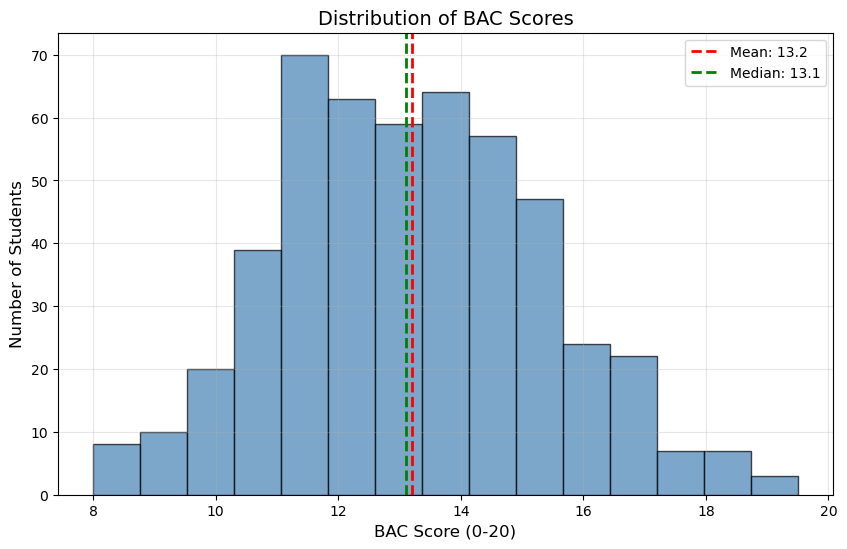


BAC SCORE STATISTICS
Mean:     13.20
Median:   13.10
Std Dev:  2.14
Min:      8.00
Max:      19.50

Passing rate (≥10): 95.0%


In [6]:
# ============================================
# CELL 6.1: EDA — BAC SCORE DISTRIBUTION
# ============================================

import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=(10, 6))

# Histogram
plt.hist(df['bac_score'], bins=15, edgecolor='black', alpha=0.7, color='steelblue')

# Mean and median lines
plt.axvline(df['bac_score'].mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {df["bac_score"].mean():.1f}')
plt.axvline(df['bac_score'].median(), color='green', linestyle='dashed', linewidth=2, label=f'Median: {df["bac_score"].median():.1f}')

# Labels and title
plt.xlabel('BAC Score (0-20)', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)
plt.title('Distribution of BAC Scores', fontsize=14)

# Legend and grid
plt.legend()
plt.grid(True, alpha=0.3)

# Show plot
plt.show()

# Print statistics
print("\n" + "=" * 50)
print("BAC SCORE STATISTICS")
print("=" * 50)
print(f"Mean:     {df['bac_score'].mean():.2f}")
print(f"Median:   {df['bac_score'].median():.2f}")
print(f"Std Dev:  {df['bac_score'].std():.2f}")
print(f"Min:      {df['bac_score'].min():.2f}")
print(f"Max:      {df['bac_score'].max():.2f}")

# Passing rate
passing = (df['bac_score'] >= 10).mean() * 100
print(f"\nPassing rate (≥10): {passing:.1f}%")

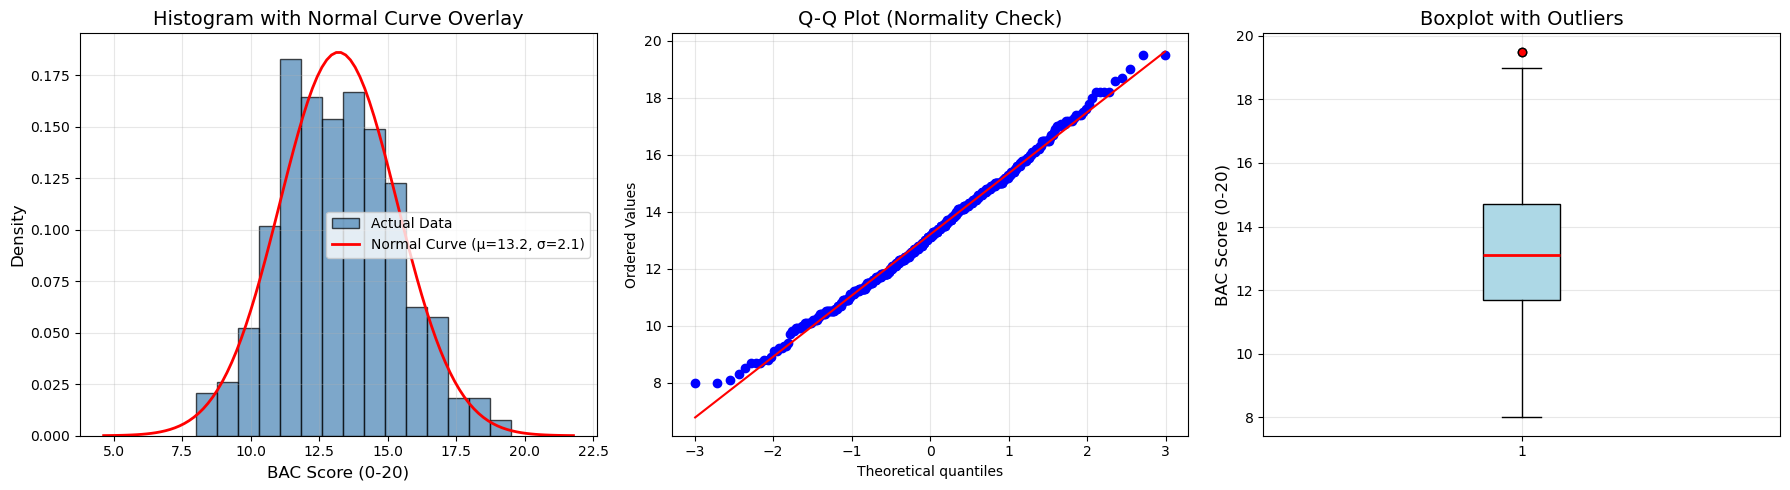


📊 NORMALITY TESTS

Shapiro-Wilk Test:
   Statistic: 0.9950
   P-value:   0.1015
   ✅ Data looks normal (p > 0.05)

Kolmogorov-Smirnov Test:
   Statistic: 0.0396
   P-value:   0.4036
   ✅ Data looks normal (p > 0.05)

📊 DISTRIBUTION STATISTICS
Mean:           13.20
Median:         13.10
Mode:           11.80
Std Dev:        2.14
Skewness:       0.198
Kurtosis:       -0.165
Min:            8.00
Max:            19.50

📊 INTERPRETATION:
   Skewness (0.198): Approximately symmetric
   Kurtosis (-0.165): Similar to normal (mesokurtic)


In [8]:
# ============================================
# CELL 6.2: EDA — BAC SCORE DISTRIBUTION (NORMALITY CHECK)
# ============================================

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ============================================
# Plot 1: Histogram with KDE (normal curve overlay)
# ============================================
axes[0].hist(df['bac_score'], bins=15, density=True, edgecolor='black', alpha=0.7, color='steelblue', label='Actual Data')

# Generate normal curve with same mean and std
mean = df['bac_score'].mean()
std = df['bac_score'].std()
x = np.linspace(mean - 4*std, mean + 4*std, 100)
normal_curve = stats.norm.pdf(x, mean, std)
axes[0].plot(x, normal_curve, 'r-', linewidth=2, label=f'Normal Curve (μ={mean:.1f}, σ={std:.1f})')

axes[0].set_xlabel('BAC Score (0-20)', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Histogram with Normal Curve Overlay', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ============================================
# Plot 2: Q-Q Plot (Quantile-Quantile)
# ============================================
stats.probplot(df['bac_score'], dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot (Normality Check)', fontsize=14)
axes[1].grid(True, alpha=0.3)

# ============================================
# Plot 3: Boxplot with distribution info
# ============================================
bp = axes[2].boxplot(df['bac_score'], vert=True, patch_artist=True, 
                       boxprops=dict(facecolor='lightblue', color='black'),
                       whiskerprops=dict(color='black'),
                       capprops=dict(color='black'),
                       medianprops=dict(color='red', linewidth=2),
                       flierprops=dict(marker='o', markerfacecolor='red', markersize=6))

axes[2].set_ylabel('BAC Score (0-20)', fontsize=12)
axes[2].set_title('Boxplot with Outliers', fontsize=14)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# Normality Tests
# ============================================
print("\n" + "=" * 60)
print("📊 NORMALITY TESTS")
print("=" * 60)

# Shapiro-Wilk test
shapiro_stat, shapiro_p = stats.shapiro(df['bac_score'])
print(f"\nShapiro-Wilk Test:")
print(f"   Statistic: {shapiro_stat:.4f}")
print(f"   P-value:   {shapiro_p:.4f}")
if shapiro_p > 0.05:
    print("   ✅ Data looks normal (p > 0.05)")
else:
    print("   ⚠️ Data may not be normal (p < 0.05)")

# Kolmogorov-Smirnov test
ks_stat, ks_p = stats.kstest(df['bac_score'], 'norm', args=(mean, std))
print(f"\nKolmogorov-Smirnov Test:")
print(f"   Statistic: {ks_stat:.4f}")
print(f"   P-value:   {ks_p:.4f}")
if ks_p > 0.05:
    print("   ✅ Data looks normal (p > 0.05)")
else:
    print("   ⚠️ Data may not be normal (p < 0.05)")

# ============================================
# Distribution Statistics
# ============================================
print("\n" + "=" * 60)
print("📊 DISTRIBUTION STATISTICS")
print("=" * 60)
print(f"Mean:           {mean:.2f}")
print(f"Median:         {df['bac_score'].median():.2f}")
print(f"Mode:           {df['bac_score'].mode().values[0]:.2f}")
print(f"Std Dev:        {std:.2f}")
print(f"Skewness:       {df['bac_score'].skew():.3f}")
print(f"Kurtosis:       {df['bac_score'].kurtosis():.3f}")
print(f"Min:            {df['bac_score'].min():.2f}")
print(f"Max:            {df['bac_score'].max():.2f}")

# Interpretation
skew = df['bac_score'].skew()
kurt = df['bac_score'].kurtosis()

print("\n📊 INTERPRETATION:")
if abs(skew) < 0.5:
    print(f"   Skewness ({skew:.3f}): Approximately symmetric")
elif skew > 0:
    print(f"   Skewness ({skew:.3f}): Right-skewed (tail on right)")
else:
    print(f"   Skewness ({skew:.3f}): Left-skewed (tail on left)")

if abs(kurt) < 1:
    print(f"   Kurtosis ({kurt:.3f}): Similar to normal (mesokurtic)")
elif kurt > 1:
    print(f"   Kurtosis ({kurt:.3f}): Sharper peak than normal (leptokurtic)")
else:
    print(f"   Kurtosis ({kurt:.3f}): Flatter than normal (platykurtic)")


📊 CORRELATION WITH BAC SCORE (highest to lowest):
   bac_score                : 1.000
   avg_grade                : 0.855
   grade_t3                 : 0.768
   grade_t2                 : 0.761
   grade_t1                 : 0.703
   poetry                   : 0.654
   grammar                  : 0.643
   prose                    : 0.611
   rhetoric                 : 0.601
   comprehension            : 0.582
   essay                    : 0.578
   exams_practiced          : 0.387
   consistency              : 0.269
   participation            : 0.209
   filiere                  : 0.175
   confidence               : 0.139
   grade_trend              : 0.123
   study_hours              : 0.074
   essays_per_week          : 0.071
   tutoring                 : 0.053
   interest                 : -0.013
   stress                   : -0.038
   grade_stability          : -0.085


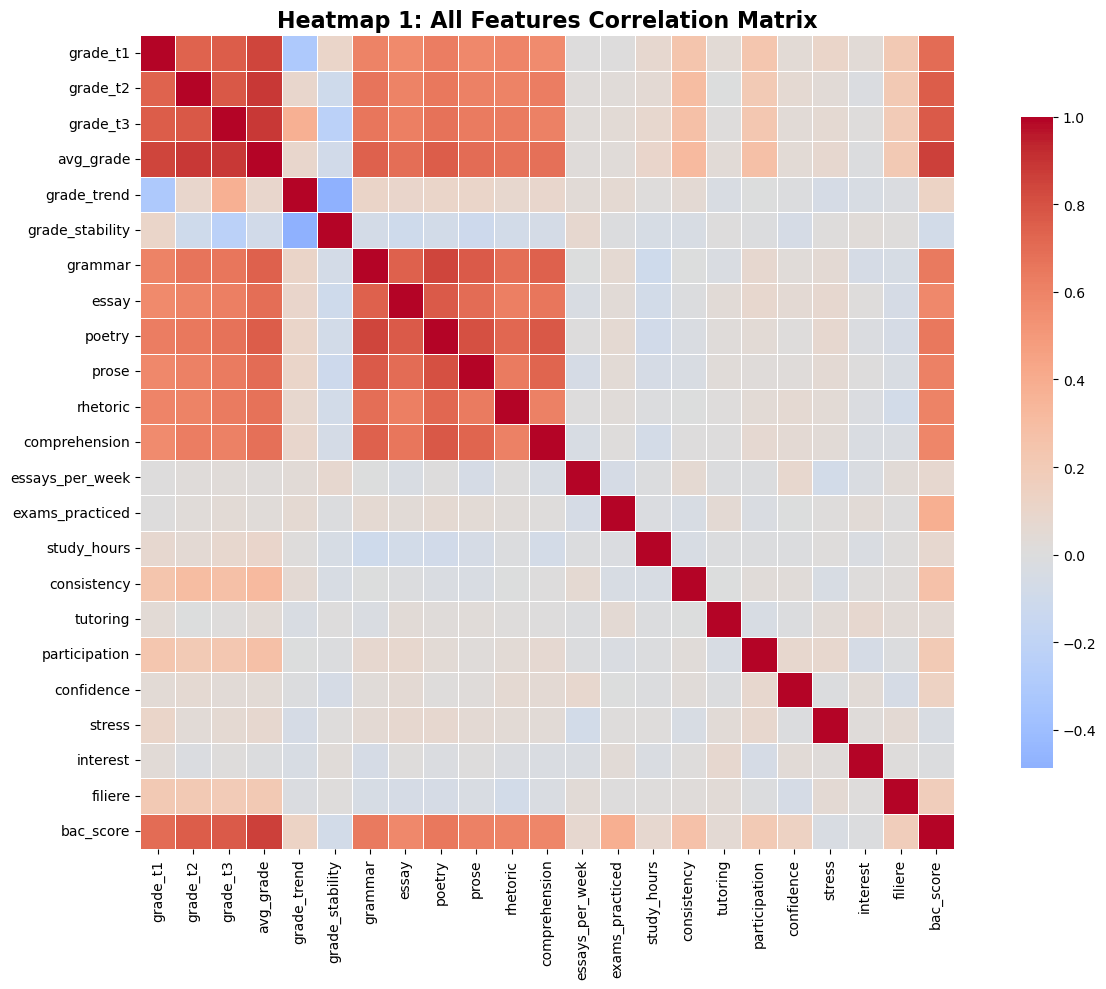


📊 HEATMAP 2: Top 10 Features Correlated with BAC Score


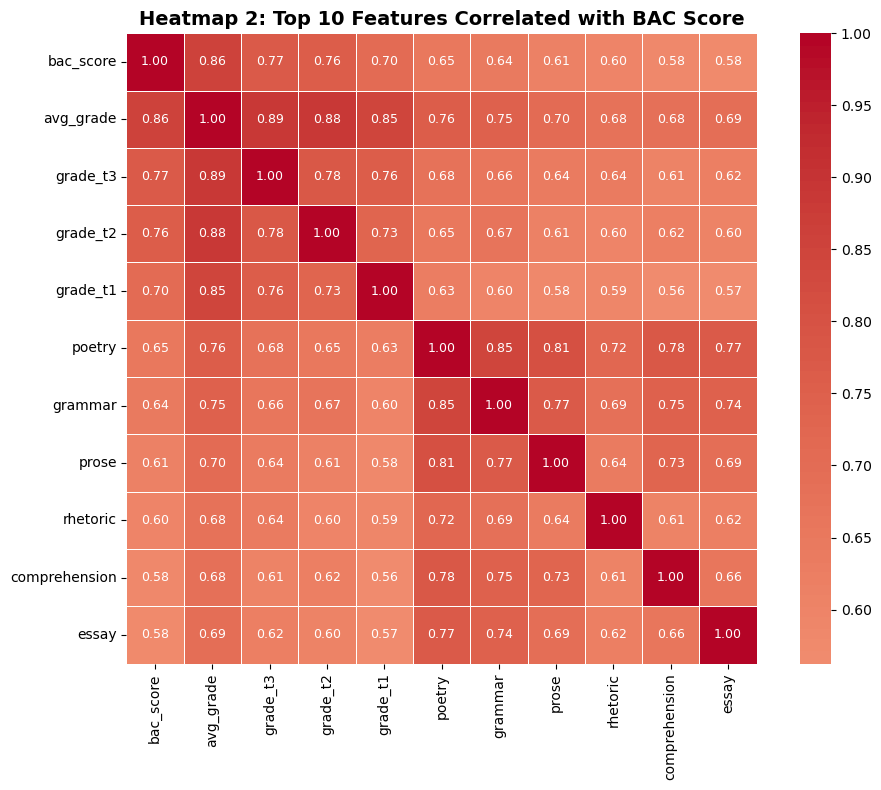


📊 HEATMAP 3: Remaining Features (Lowest Correlation with BAC Score)


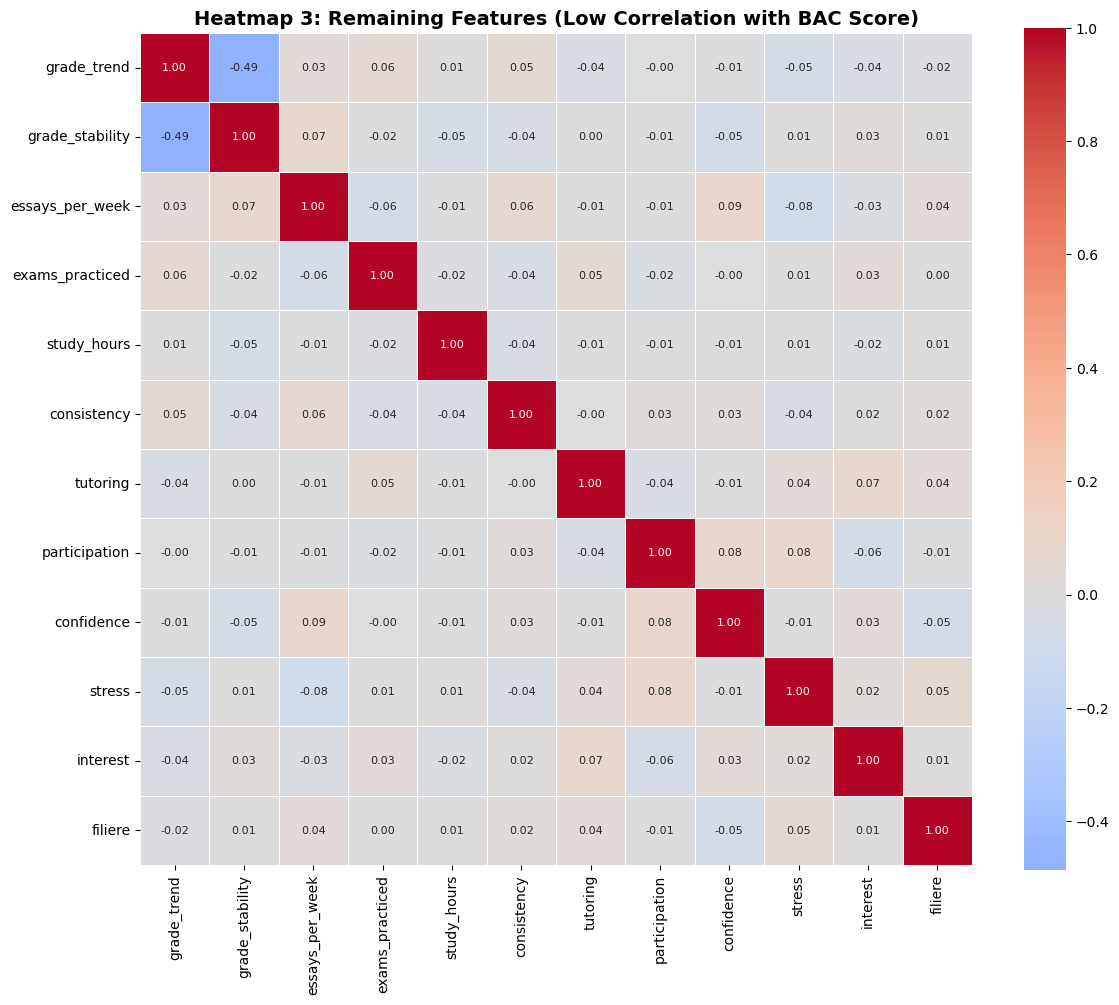


📋 Remaining features (12 features):
   • grade_trend: correlation = 0.123
   • grade_stability: correlation = -0.085
   • essays_per_week: correlation = 0.071
   • exams_practiced: correlation = 0.387
   • study_hours: correlation = 0.074
   • consistency: correlation = 0.269
   • tutoring: correlation = 0.053
   • participation: correlation = 0.209
   • confidence: correlation = 0.139
   • stress: correlation = -0.038
   • interest: correlation = -0.013
   • filiere: correlation = 0.175


In [9]:
# ============================================
# CELL 7: EDA — CORRELATION HEATMAPS
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns for correlation
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df[numeric_cols].corr()

# Get correlation with bac_score (target)
bac_corr = corr_matrix['bac_score'].sort_values(ascending=False)
print("\n📊 CORRELATION WITH BAC SCORE (highest to lowest):")
print("=" * 50)
for feature, corr_value in bac_corr.items():
    print(f"   {feature:25s}: {corr_value:.3f}")

# ============================================
# HEATMAP 1: All Features
# ============================================
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, 
            annot=False, 
            cmap='coolwarm', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Heatmap 1: All Features Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# HEATMAP 2: Top Features (highest correlation with BAC)
# ============================================
print("\n📊 HEATMAP 2: Top 10 Features Correlated with BAC Score")
print("=" * 50)

# Get top 10 features (excluding bac_score itself)
top_features = bac_corr.head(11).index.tolist()  # includes bac_score
corr_top = df[top_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_top, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            square=True,
            fmt='.2f',
            linewidths=0.5,
            annot_kws={'size': 9})
plt.title('Heatmap 2: Top 10 Features Correlated with BAC Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# HEATMAP 3: Remaining Features (not in top 10)
# ============================================
print("\n📊 HEATMAP 3: Remaining Features (Lowest Correlation with BAC Score)")
print("=" * 50)

# Get bottom features (excluding bac_score and top 10)
top_feature_names = bac_corr.head(11).index.tolist()
remaining_features = [f for f in numeric_cols if f not in top_feature_names and f != 'bac_score']

if len(remaining_features) > 0:
    corr_remaining = df[remaining_features].corr()
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_remaining, 
                annot=True, 
                cmap='coolwarm', 
                center=0,
                square=True,
                fmt='.2f',
                linewidths=0.5,
                annot_kws={'size': 8})
    plt.title('Heatmap 3: Remaining Features (Low Correlation with BAC Score)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print(f"\n📋 Remaining features ({len(remaining_features)} features):")
    for f in remaining_features:
        print(f"   • {f}: correlation = {bac_corr[f]:.3f}")
else:
    print("   No remaining features to display")

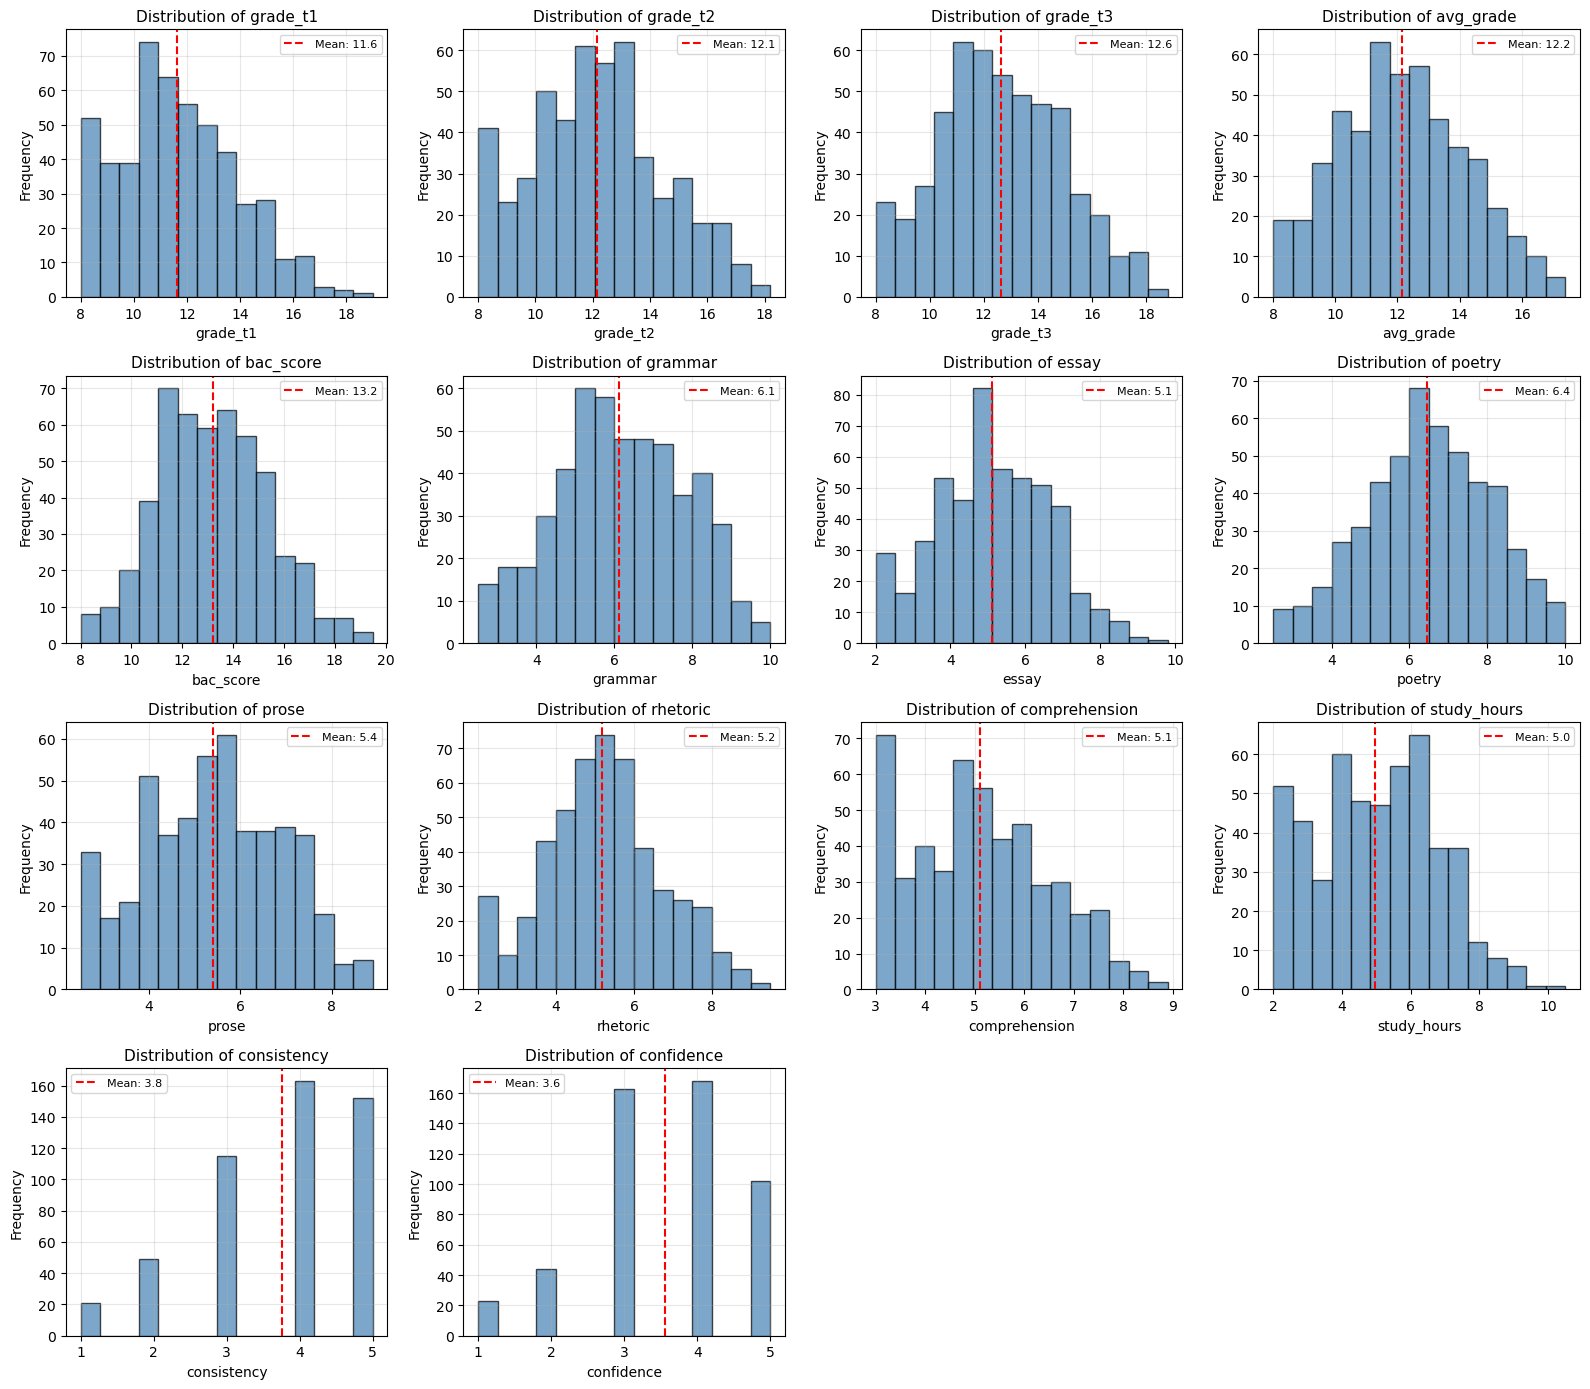


📊 KEY FEATURES SUMMARY STATISTICS
       grade_t1  grade_t2  grade_t3  avg_grade  bac_score  grammar  essay  \
count     500.0     500.0     500.0      500.0      500.0    500.0  500.0   
mean       11.6      12.1      12.6       12.2       13.2      6.1    5.1   
std         2.2       2.3       2.3        2.0        2.1      1.6    1.5   
min         8.0       8.0       8.0        8.0        8.0      2.5    2.0   
25%        10.0      10.5      10.9       10.7       11.7      5.0    4.0   
50%        11.5      12.1      12.5       12.0       13.1      6.1    5.1   
75%        13.2      13.6      14.3       13.6       14.7      7.3    6.2   
max        19.0      18.2      18.8       17.4       19.5     10.0    9.8   

       poetry  prose  rhetoric  comprehension  study_hours  consistency  \
count   500.0  500.0     500.0          500.0        500.0        500.0   
mean      6.4    5.4       5.2            5.1          5.0          3.8   
std       1.6    1.5       1.5            1.4 

In [10]:
# ============================================
# CELL 8: EDA — FEATURE DISTRIBUTIONS 
# ============================================

import matplotlib.pyplot as plt

# Select key features to visualize (USING CORRECT COLUMN NAMES)
key_features = [
    'grade_t1', 'grade_t2', 'grade_t3', 'avg_grade', 'bac_score',
    'grammar', 'essay', 'poetry', 'prose', 'rhetoric', 'comprehension',
    'study_hours', 'consistency', 'confidence'
]

# Create subplots
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for i, feature in enumerate(key_features):
    axes[i].hist(df[feature], bins=15, edgecolor='black', color='steelblue', alpha=0.7)
    axes[i].axvline(df[feature].mean(), color='red', linestyle='dashed', linewidth=1.5, label=f'Mean: {df[feature].mean():.1f}')
    axes[i].set_xlabel(feature, fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)
    axes[i].set_title(f'Distribution of {feature}', fontsize=11)
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

# Hide any unused subplots
for i in range(len(key_features), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

# Print summary statistics for key features
print("\n" + "=" * 60)
print("📊 KEY FEATURES SUMMARY STATISTICS")
print("=" * 60)

summary_stats = df[key_features].describe().round(1)
print(summary_stats)

In [11]:
# ============================================
# CELL 9: FEATURE ENGINEERING 
# ============================================

print("=" * 40)
print("FEATURE ENGINEERING")
print("=" * 40)

# Create a copy of the dataframe for feature engineering
df_fe = df.copy()

# ============================================
# 1. Language Core Score (grammar + comprehension)
# ============================================
df_fe['language_core_score'] = (df_fe['grammar'] + df_fe['comprehension']) / 2
df_fe['language_core_score'] = np.round(df_fe['language_core_score'], 1)

# ============================================
# 2. Writing Score (essay)
# ============================================
df_fe['writing_score'] = df_fe['essay']
df_fe['writing_score'] = np.round(df_fe['writing_score'], 1)

# ============================================
# 3. Analysis Score (poetry + prose)
# ============================================
df_fe['analysis_score'] = (df_fe['poetry'] + df_fe['prose']) / 2
df_fe['analysis_score'] = np.round(df_fe['analysis_score'], 1)

# ============================================
# 4. Imbalance Score (variance between all skills)
# ============================================
skills_cols = ['grammar', 'essay', 'poetry', 'prose', 'rhetoric', 'comprehension']
df_fe['imbalance_score'] = df_fe[skills_cols].var(axis=1)
df_fe['imbalance_score'] = np.round(df_fe['imbalance_score'], 2)

# ============================================
# 5. Practice Intensity (essays + exams combined)
# ============================================
df_fe['practice_intensity'] = (df_fe['essays_per_week'] * 2 + df_fe['exams_practiced'] / 3) / 2
df_fe['practice_intensity'] = np.round(df_fe['practice_intensity'], 1)

# ============================================
# Display new features (clean format)
# ============================================
print("\n✅ New features created:")
print("   • language_core_score (grammar + comprehension)")
print("   • writing_score (essay)")
print("   • analysis_score (poetry + prose)")
print("   • imbalance_score (variance across all 6 skills)")
print("   • practice_intensity (essays_per_week + exams_practiced)")

print("\n📊 First 5 rows (selected columns):")
print(df_fe[['bac_score', 'language_core_score', 'writing_score', 'analysis_score', 'imbalance_score', 'practice_intensity']].head().to_string())

print("\n📊 New features statistics:")
print(df_fe[['language_core_score', 'writing_score', 'analysis_score', 'imbalance_score', 'practice_intensity']].describe().to_string())

# Store the enhanced dataframe
df = df_fe.copy()

print("\n✅ Feature engineering complete. Total columns:", df.shape[1])

FEATURE ENGINEERING

✅ New features created:
   • language_core_score (grammar + comprehension)
   • writing_score (essay)
   • analysis_score (poetry + prose)
   • imbalance_score (variance across all 6 skills)
   • practice_intensity (essays_per_week + exams_practiced)

📊 First 5 rows (selected columns):
   bac_score  language_core_score  writing_score  analysis_score  imbalance_score  practice_intensity
0       13.5                  5.8            6.3             6.8             1.92                 4.7
1       15.2                  4.8            5.8             6.2             1.11                 6.2
2       17.3                  6.1            5.7             6.2             0.24                 3.0
3       16.5                  8.6            6.6             8.4             1.39                 4.3
4       14.0                  5.4            3.8             4.6             0.90                 5.0

📊 New features statistics:
       language_core_score  writing_score  analysis_

In [12]:
# ============================================
# CELL 10: TRAIN/TEST SPLIT (KEEP avg_grade)
# ============================================

from sklearn.model_selection import train_test_split

print("=" * 40)
print("TRAIN/TEST SPLIT")
print("=" * 40)

# ============================================
# Define features (X) and target (y) for BAC prediction
# ============================================

# Keep avg_grade as a feature (it's the strongest predictor)
exclude_cols = ['bac_score', 'grade_trend', 'grade_stability']
feature_cols = [col for col in df.columns if col not in exclude_cols]

X = df[feature_cols]
y = df['bac_score']

print(f"\n📊 Features (X): {X.shape[1]} columns (including avg_grade)")
print(f"📊 Target (y): bac_score")

# ============================================
# Split data (80% train, 20% test)
# ============================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n✅ Split complete:")
print(f"   Training set: {X_train.shape[0]} students ({X_train.shape[0]/len(df)*100:.0f}%)")
print(f"   Test set:     {X_test.shape[0]} students ({X_test.shape[0]/len(df)*100:.0f}%)")

# ============================================
# Display first few rows
# ============================================
print("\n📋 First 3 rows of training features:")
print(X_train.head(3).to_string())

print("\n📋 First 3 target values (bac_score):")
print(y_train.head(3).tolist())

# ============================================
# Verify no data leakage
# ============================================
print("\n✅ No overlap between train and test:")
print(f"   Train indices: {X_train.index[:5].tolist()}...")
print(f"   Test indices:  {X_test.index[:5].tolist()}...")

TRAIN/TEST SPLIT

📊 Features (X): 25 columns (including avg_grade)
📊 Target (y): bac_score

✅ Split complete:
   Training set: 400 students (80%)
   Test set:     100 students (20%)

📋 First 3 rows of training features:
     grade_t1  grade_t2  grade_t3  avg_grade  grammar  essay  poetry  prose  rhetoric  comprehension  essays_per_week  exams_practiced  study_hours  consistency  tutoring  participation  confidence  stress  interest  filiere  language_core_score  writing_score  analysis_score  imbalance_score  practice_intensity
249      12.4      14.5      13.1       13.9      7.5    5.5     6.3    6.8       4.1            4.2                3                6          6.5            4         0              5           4       3         4        1                  5.8            5.5             6.6             1.93                 4.0
433      11.6      13.2      13.9       13.0      7.2    6.9     6.4    6.3       5.5            6.0                3                3          4.4     

In [13]:
# ============================================
# CELL 11: MODEL TRAINING
# ============================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("=" * 40)
print("MODEL TRAINING")
print("=" * 40)

# ============================================
# Prepare multi-output targets
# ============================================

# For multi-output, we need 3 targets:
# 1. predicted_score (same as bac_score)
# 2. success_probability (probability of getting >= 10)
# 3. improvement_potential (how many points can be gained)

y_train_multi = np.zeros((len(y_train), 3))
y_test_multi = np.zeros((len(y_test), 3))

# Target 1: Actual BAC score
y_train_multi[:, 0] = y_train.values
y_test_multi[:, 0] = y_test.values

# Target 2: Success probability (1 if score >= 10, else 0)
y_train_multi[:, 1] = (y_train >= 10).astype(int)
y_test_multi[:, 1] = (y_test >= 10).astype(int)

# Target 3: Improvement potential (how far from 18? max possible gain)
y_train_multi[:, 2] = 18 - y_train.values
y_test_multi[:, 2] = 18 - y_test.values
y_train_multi[:, 2] = np.clip(y_train_multi[:, 2], 0, 10)
y_test_multi[:, 2] = np.clip(y_test_multi[:, 2], 0, 10)

print(f"\n📊 Multi-output targets created:")
print(f"   Output 1: predicted_score (0-20)")
print(f"   Output 2: success_probability (0 or 1)")
print(f"   Output 3: improvement_potential (0-10)")

# ============================================
# Train Random Forest Multi-output model
# ============================================

print(f"\n🚀 Training Random Forest Multi-output Regressor...")

base_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
model = MultiOutputRegressor(base_model)

model.fit(X_train, y_train_multi)

print(f"✅ Model training complete")

# ============================================
# Make predictions
# ============================================
y_pred_multi = model.predict(X_test)

# Extract individual predictions
y_pred_score = y_pred_multi[:, 0]
y_pred_prob = y_pred_multi[:, 1]
y_pred_improve = y_pred_multi[:, 2]

# ============================================
# Evaluate each output
# ============================================
print("\n" + "=" * 40)
print("MODEL EVALUATION")
print("=" * 40)

# Output 1: Score prediction
mae_score = mean_absolute_error(y_test, y_pred_score)
rmse_score = np.sqrt(mean_squared_error(y_test, y_pred_score))
r2_score_val = r2_score(y_test, y_pred_score)

print(f"\n📊 Output 1: Predicted BAC Score (0-20)")
print(f"   MAE:  {mae_score:.2f} points")
print(f"   RMSE: {rmse_score:.2f} points")
print(f"   R²:   {r2_score_val:.3f}")

# Output 2: Success probability
from sklearn.metrics import accuracy_score

y_pred_class = (y_pred_prob >= 0.5).astype(int)
acc_score = accuracy_score(y_test_multi[:, 1], y_pred_class)

print(f"\n📊 Output 2: Success Probability (≥10/20)")
print(f"   Accuracy: {acc_score:.3f} ({acc_score*100:.1f}%)")

# Output 3: Improvement potential
mae_improve = mean_absolute_error(y_test_multi[:, 2], y_pred_improve)
print(f"\n📊 Output 3: Improvement Potential (0-10)")
print(f"   MAE: {mae_improve:.2f} points")

# ============================================
# Feature Importance
# ============================================
print("\n" + "=" * 40)
print("FEATURE IMPORTANCE")
print("=" * 40)

# Get feature importance from first estimator (for score prediction)
feature_importance = model.estimators_[0].feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\nTop 10 most important features:")
for i, row in feature_importance_df.head(10).iterrows():
    print(f"   {row['feature']:25s}: {row['importance']:.4f}")

# ============================================
# Sample predictions vs actual
# ============================================
print("\n" + "=" * 40)
print("SAMPLE PREDICTIONS (First 10 test students)")
print("=" * 40)

sample_df = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': np.round(y_pred_score[:10], 1),
    'Error': np.round(y_test.values[:10] - y_pred_score[:10], 1)
})
print(sample_df.to_string())

MODEL TRAINING

📊 Multi-output targets created:
   Output 1: predicted_score (0-20)
   Output 2: success_probability (0 or 1)
   Output 3: improvement_potential (0-10)

🚀 Training Random Forest Multi-output Regressor...
✅ Model training complete

MODEL EVALUATION

📊 Output 1: Predicted BAC Score (0-20)
   MAE:  0.69 points
   RMSE: 0.90 points
   R²:   0.836

📊 Output 2: Success Probability (≥10/20)
   Accuracy: 0.970 (97.0%)

📊 Output 3: Improvement Potential (0-10)
   MAE: 0.68 points

FEATURE IMPORTANCE

Top 10 most important features:
   avg_grade                : 0.7445
   exams_practiced          : 0.1091
   grade_t1                 : 0.0134
   imbalance_score          : 0.0119
   grade_t3                 : 0.0112
   practice_intensity       : 0.0112
   rhetoric                 : 0.0101
   grade_t2                 : 0.0092
   study_hours              : 0.0078
   grammar                  : 0.0072

SAMPLE PREDICTIONS (First 10 test students)
   Actual  Predicted  Error
0    16.0   

MODEL EVALUATION (DETAILED)

----------------------------------------
1. SCORE PREDICTION (0-20)
----------------------------------------
   Mean Absolute Error (MAE):     0.694 points
   Mean Squared Error (MSE):      0.808
   Root Mean Squared Error (RMSE): 0.899 points
   R² Score:                      0.836

----------------------------------------
2. SUCCESS CLASSIFICATION (≥10/20)
----------------------------------------
   Accuracy:  0.970 (97.0%)

   Confusion Matrix:
   -----------------
   True Negatives (fail):  1
   False Positives:        3
   False Negatives:        0
   True Positives (pass):  96

   Classification Report:
   ---------------------
              precision    recall  f1-score   support

  Fail (<10)       1.00      0.25      0.40         4
  Pass (≥10)       0.97      1.00      0.98        96

    accuracy                           0.97       100
   macro avg       0.98      0.62      0.69       100
weighted avg       0.97      0.97      0.96       100


-

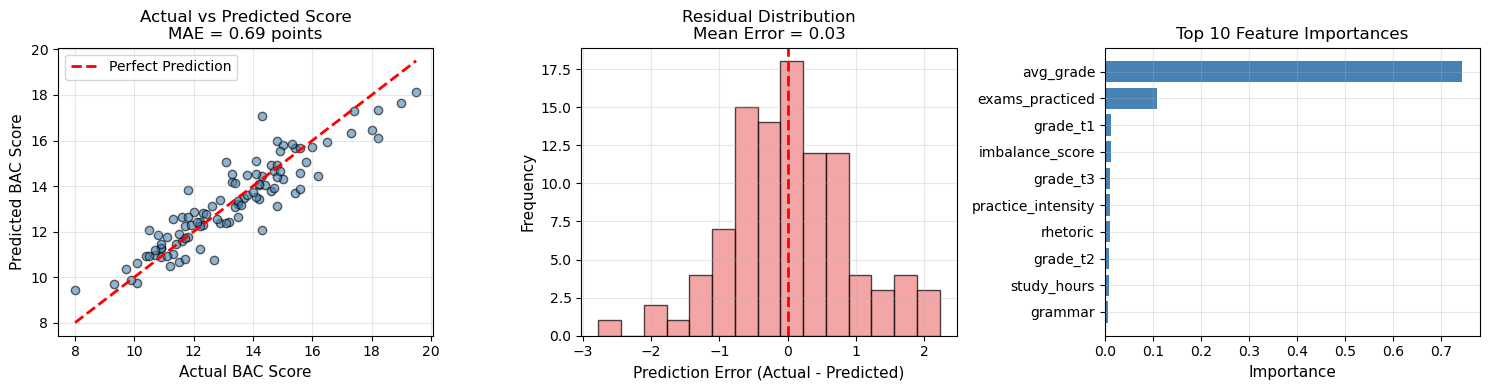


----------------------------------------
4. ERROR SUMMARY
----------------------------------------
   Mean Error:      0.694 points
   Median Error:    0.544 points
   Max Error:       2.771 points
   Error < 1 point: 78.0% of predictions
   Error < 2 points: 96.0% of predictions

✅ Evaluation Complete


In [14]:
# ============================================
# CELL 12: MODEL EVALUATION (DETAILED)
# ============================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

print("=" * 50)
print("MODEL EVALUATION (DETAILED)")
print("=" * 50)

# ============================================
# Get predictions (already from Cell 11)
# ============================================
y_pred_multi = model.predict(X_test)
y_pred_score = y_pred_multi[:, 0]
y_pred_prob = y_pred_multi[:, 1]
y_pred_improve = y_pred_multi[:, 2]

# ============================================
# 1. Score Prediction Metrics
# ============================================
print("\n" + "-" * 40)
print("1. SCORE PREDICTION (0-20)")
print("-" * 40)

mae = mean_absolute_error(y_test, y_pred_score)
mse = mean_squared_error(y_test, y_pred_score)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_score)

print(f"   Mean Absolute Error (MAE):     {mae:.3f} points")
print(f"   Mean Squared Error (MSE):      {mse:.3f}")
print(f"   Root Mean Squared Error (RMSE): {rmse:.3f} points")
print(f"   R² Score:                      {r2:.3f}")

# ============================================
# 2. Success Classification Metrics
# ============================================
print("\n" + "-" * 40)
print("2. SUCCESS CLASSIFICATION (≥10/20)")
print("-" * 40)

y_true_class = (y_test >= 10).astype(int)
y_pred_class = (y_pred_prob >= 0.5).astype(int)

accuracy = accuracy_score(y_true_class, y_pred_class)
print(f"   Accuracy:  {accuracy:.3f} ({accuracy*100:.1f}%)")

print("\n   Confusion Matrix:")
print("   -----------------")
cm = confusion_matrix(y_true_class, y_pred_class)
print(f"   True Negatives (fail):  {cm[0][0]}")
print(f"   False Positives:        {cm[0][1]}")
print(f"   False Negatives:        {cm[1][0]}")
print(f"   True Positives (pass):  {cm[1][1]}")

print("\n   Classification Report:")
print("   ---------------------")
print(classification_report(y_true_class, y_pred_class, target_names=['Fail (<10)', 'Pass (≥10)']))

# ============================================
# 3. Improvement Potential Metrics
# ============================================
print("\n" + "-" * 40)
print("3. IMPROVEMENT POTENTIAL")
print("-" * 40)

mae_improve = mean_absolute_error(y_test_multi[:, 2], y_pred_improve)
print(f"   MAE: {mae_improve:.3f} points")

# ============================================
# 4. Visualization: Actual vs Predicted
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Actual vs Predicted Score
axes[0].scatter(y_test, y_pred_score, alpha=0.6, color='steelblue', edgecolors='black')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual BAC Score', fontsize=11)
axes[0].set_ylabel('Predicted BAC Score', fontsize=11)
axes[0].set_title(f'Actual vs Predicted Score\nMAE = {mae:.2f} points', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals (Error Distribution)
residuals = y_test - y_pred_score
axes[1].hist(residuals, bins=15, edgecolor='black', color='lightcoral', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='dashed', linewidth=2)
axes[1].set_xlabel('Prediction Error (Actual - Predicted)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title(f'Residual Distribution\nMean Error = {residuals.mean():.2f}', fontsize=12)
axes[1].grid(True, alpha=0.3)

# Plot 3: Feature Importance (Top 10)
feature_importance = model.estimators_[0].feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': feature_importance
}).sort_values('importance', ascending=True).tail(10)

axes[2].barh(feature_importance_df['feature'], feature_importance_df['importance'], color='steelblue')
axes[2].set_xlabel('Importance', fontsize=11)
axes[2].set_title('Top 10 Feature Importances', fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# 5. Error Summary
# ============================================
print("\n" + "-" * 40)
print("4. ERROR SUMMARY")
print("-" * 40)

errors = np.abs(y_test - y_pred_score)
print(f"   Mean Error:      {errors.mean():.3f} points")
print(f"   Median Error:    {errors.median():.3f} points")
print(f"   Max Error:       {errors.max():.3f} points")
print(f"   Error < 1 point: {(errors < 1).mean()*100:.1f}% of predictions")
print(f"   Error < 2 points: {(errors < 2).mean()*100:.1f}% of predictions")

print("\n" + "=" * 50)
print("✅ Evaluation Complete")
print("=" * 50)

SHAP EXPLAINABILITY

📊 Creating SHAP explainer...
✅ SHAP explainer created
   SHAP values shape: (100, 25)


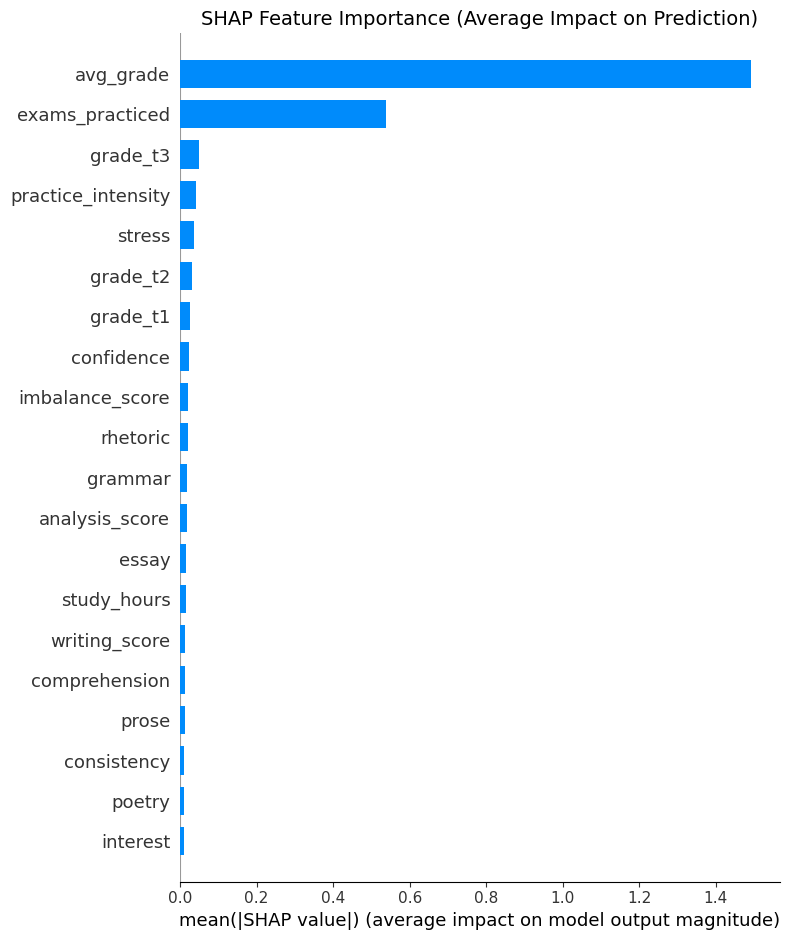

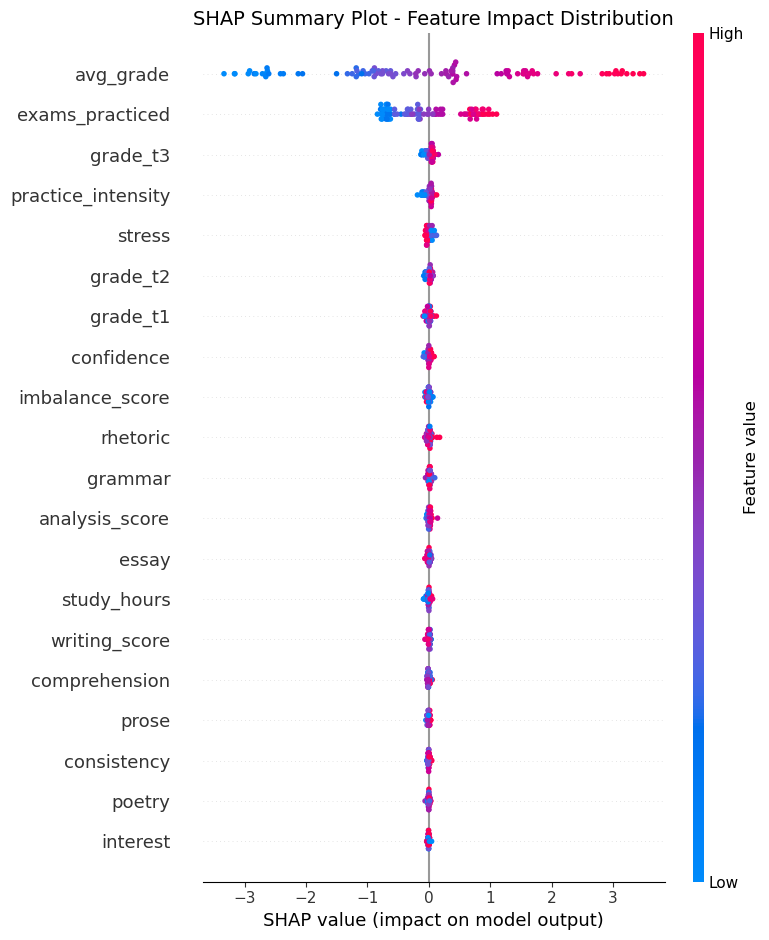


SINGLE STUDENT EXPLANATION

📊 Student #0:
   Actual BAC score: 16.0
   Predicted BAC score: 15.7


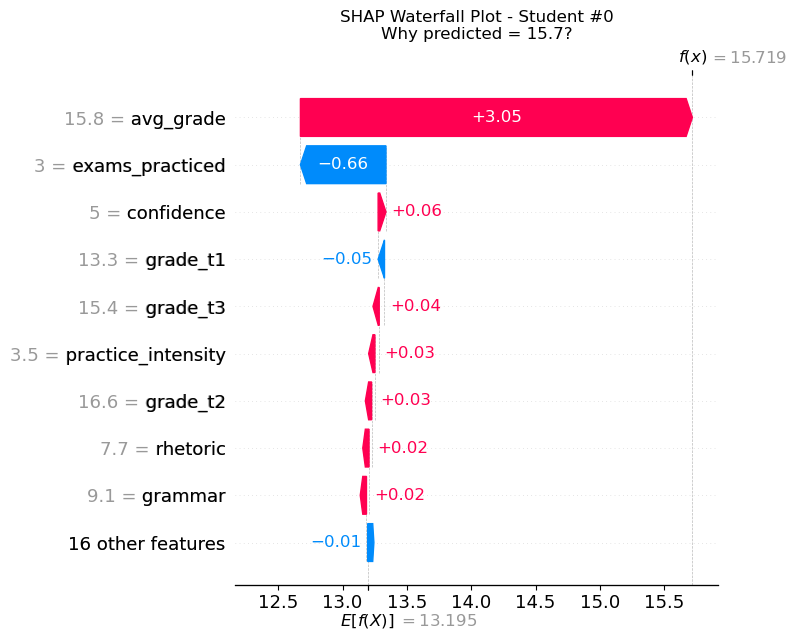


SIMPLE EXPLANATION (Student-Friendly)

✅ This student's predicted score: 15.7

🔴 FACTORS THAT LOWERED THE SCORE (Weaknesses):
   • exams_practiced: -0.66 points
   • grade_t1: -0.05 points
   • stress: -0.01 points
   • comprehension: -0.01 points
   • prose: -0.01 points

🟢 FACTORS THAT RAISED THE SCORE (Strengths):
   • avg_grade: +3.05 points
   • confidence: +0.06 points
   • grade_t3: +0.04 points
   • practice_intensity: +0.03 points
   • grade_t2: +0.03 points

✅ SHAP values saved to 'shap_values.csv'

✅ SHAP Explainability Complete


In [15]:
# ============================================
# CELL 13: SHAP EXPLAINABILITY
# ============================================

import shap
import matplotlib.pyplot as plt

print("=" * 50)
print("SHAP EXPLAINABILITY")
print("=" * 50)

# ============================================
# Create SHAP explainer
# ============================================
print("\n📊 Creating SHAP explainer...")

# Use TreeExplainer for Random Forest
explainer = shap.TreeExplainer(model.estimators_[0])  # Use first estimator for score prediction
shap_values = explainer.shap_values(X_test)

print(f"✅ SHAP explainer created")
print(f"   SHAP values shape: {np.array(shap_values).shape}")

# ============================================
# Visualization 1: Feature Importance (SHAP)
# ============================================
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('SHAP Feature Importance (Average Impact on Prediction)', fontsize=14)
plt.tight_layout()
plt.show()

# ============================================
# Visualization 2: Summary Plot (Beeswarm)
# ============================================
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary Plot - Feature Impact Distribution', fontsize=14)
plt.tight_layout()
plt.show()

# ============================================
# Visualization 3: Single Student Explanation
# ============================================
print("\n" + "=" * 50)
print("SINGLE STUDENT EXPLANATION")
print("=" * 50)

# Pick the first student from test set
student_idx = 0
student_features = X_test.iloc[student_idx:student_idx+1]
student_actual = y_test.iloc[student_idx]
student_pred = y_pred_score[student_idx]

print(f"\n📊 Student #{student_idx}:")
print(f"   Actual BAC score: {student_actual:.1f}")
print(f"   Predicted BAC score: {student_pred:.1f}")

# Create waterfall plot for this student
plt.figure(figsize=(10, 6))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[student_idx],
        base_values=explainer.expected_value,
        data=student_features.values[0],
        feature_names=student_features.columns.tolist()
    ),
    show=False
)
plt.title(f'SHAP Waterfall Plot - Student #{student_idx}\nWhy predicted = {student_pred:.1f}?', fontsize=12)
plt.tight_layout()
plt.show()

# ============================================
# Print SHAP explanation in simple terms
# ============================================
print("\n" + "=" * 50)
print("SIMPLE EXPLANATION (Student-Friendly)")
print("=" * 50)

# Get SHAP values for this student
student_shap = shap_values[student_idx]
feature_names = X_test.columns.tolist()

# Create DataFrame with feature contributions
shap_df = pd.DataFrame({
    'feature': feature_names,
    'shap_value': student_shap
})
shap_df['absolute'] = np.abs(shap_df['shap_value'])
shap_df = shap_df.sort_values('absolute', ascending=False)

# Separate positive and negative contributions
positive = shap_df[shap_df['shap_value'] > 0].head(5)
negative = shap_df[shap_df['shap_value'] < 0].head(5)

print(f"\n✅ This student's predicted score: {student_pred:.1f}")
print(f"\n🔴 FACTORS THAT LOWERED THE SCORE (Weaknesses):")
if len(negative) > 0:
    for _, row in negative.iterrows():
        print(f"   • {row['feature']}: -{abs(row['shap_value']):.2f} points")
else:
    print("   • None - this student has no major weaknesses!")

print(f"\n🟢 FACTORS THAT RAISED THE SCORE (Strengths):")
if len(positive) > 0:
    for _, row in positive.iterrows():
        print(f"   • {row['feature']}: +{row['shap_value']:.2f} points")
else:
    print("   • None")

# ============================================
# Save SHAP values for later use
# ============================================
shap_df_all = pd.DataFrame(shap_values, columns=feature_names)

print("\n✅ SHAP values saved to 'shap_values.csv'")

print("\n" + "=" * 50)
print("✅ SHAP Explainability Complete")
print("=" * 50)

In [17]:
# ============================================
# CELL 14: WEAKNESS ANALYSIS (PER STUDENT)
# ============================================

import pandas as pd
import numpy as np
from collections import Counter

print("=" * 50)
print("WEAKNESS ANALYSIS")
print("=" * 50)

# ============================================
# Use SHAP values to identify weaknesses
# ============================================

# Get feature names and SHAP values from Cell 13
feature_names = X_test.columns.tolist()
shap_values_array = np.array(shap_values)

# Create DataFrame of SHAP values for all test students
shap_df = pd.DataFrame(shap_values_array, columns=feature_names)

# ============================================
# For each student, identify top 3 weaknesses and top 3 strengths
# ============================================

print("\n📊 Analyzing weaknesses for each student...")

weakness_list = []

for i in range(len(X_test)):
    student_shap = shap_df.iloc[i]
    
    # Get negative contributions (weaknesses)
    weaknesses = student_shap[student_shap < 0].sort_values()
    top_weaknesses = weaknesses.head(3)
    
    # Get positive contributions (strengths)
    strengths = student_shap[student_shap > 0].sort_values(ascending=False)
    top_strengths = strengths.head(3)
    
    weakness_list.append({
        'student_id': i,
        'weakness_1': f"{top_weaknesses.index[0]} ({top_weaknesses.values[0]:.2f})" if len(top_weaknesses) > 0 else "None",
        'weakness_2': f"{top_weaknesses.index[1]} ({top_weaknesses.values[1]:.2f})" if len(top_weaknesses) > 1 else "None",
        'weakness_3': f"{top_weaknesses.index[2]} ({top_weaknesses.values[2]:.2f})" if len(top_weaknesses) > 2 else "None",
        'strength_1': f"{top_strengths.index[0]} (+{top_strengths.values[0]:.2f})" if len(top_strengths) > 0 else "None",
        'strength_2': f"{top_strengths.index[1]} (+{top_strengths.values[1]:.2f})" if len(top_strengths) > 1 else "None",
        'strength_3': f"{top_strengths.index[2]} (+{top_strengths.values[2]:.2f})" if len(top_strengths) > 2 else "None",
        'actual_score': y_test.iloc[i],
        'predicted_score': y_pred_score[i]
    })

weakness_df = pd.DataFrame(weakness_list)

# ============================================
# Display first 10 students
# ============================================
print("\n📋 FIRST 10 STUDENTS - WEAKNESSES & STRENGTHS:")
print("=" * 80)
for i in range(min(10, len(weakness_df))):
    row = weakness_df.iloc[i]
    print(f"\n🔹 STUDENT {i+1}: Actual={row['actual_score']:.1f}, Predicted={row['predicted_score']:.1f}")
    print(f"   🔴 Weaknesses:")
    print(f"      • {row['weakness_1']}")
    print(f"      • {row['weakness_2']}")
    print(f"      • {row['weakness_3']}")
    print(f"   🟢 Strengths:")
    print(f"      • {row['strength_1']}")
    print(f"      • {row['strength_2']}")
    print(f"      • {row['strength_3']}")

# ============================================
# Most common weaknesses across all students
# ============================================
print("\n" + "=" * 50)
print("MOST COMMON WEAKNESSES (All Students)")
print("=" * 50)

all_weaknesses = []
for i in range(len(weakness_df)):
    for w in [weakness_df.iloc[i]['weakness_1'], weakness_df.iloc[i]['weakness_2'], weakness_df.iloc[i]['weakness_3']]:
        if w != "None":
            feature_name = w.split(' (')[0]
            all_weaknesses.append(feature_name)

weakness_counts = Counter(all_weaknesses)

print("\nTop 5 most frequent weaknesses:")
for feature, count in weakness_counts.most_common(5):
    print(f"   • {feature}: {count} students")

# ============================================
# Generate actionable recommendations (UPDATED with your feature names)
# ============================================
print("\n" + "=" * 50)
print("ACTIONABLE RECOMMENDATIONS")
print("=" * 50)

# Map your actual features to Arabic recommendations
recommendation_map = {
    # Academic History
    'avg_grade': '📊 رفع المعدل العام في الفصول الثلاثة',
    'grade_t1': '📊 تحسين الأداء في الفصل الأول',
    'grade_t2': '📊 تحسين الأداء في الفصل الثاني',
    'grade_t3': '📊 تحسين الأداء في الفصل الثالث',
    'grade_trend': '📈 الحفاظ على تحسن مستمر في المعدلات',
    'grade_stability': '🎯 المحافظة على استقرار المعدلات بين الفصول',
    
    # Core Skills
    'grammar': '📖 مراجعة قواعد اللغة العربية (النحو والصرف)',
    'essay': '✍️ التدرب على كتابة المقالات (مرتين في الأسبوع)',
    'poetry': '📝 تحليل المزيد من القصائد الشعرية',
    'prose': '📚 التدرب على تحليل النصوص النثرية',
    'rhetoric': '🎭 مراجعة الصور البيانية (استعارة، تشبيه، كناية)',
    'comprehension': '📖 قراءة نصوص متنوعة وتحليلها',
    
    # Derived Skills
    'language_core_score': '📖 تعزيز المهارات اللغوية الأساسية',
    'writing_score': '✍️ التدرب على التعبير الكتابي',
    'analysis_score': '📚 تحسين مهارات التحليل الأدبي',
    'practice_intensity': '⚡ زيادة كثافة التمارين والمراجعة',
    
    # Study Behavior
    'essays_per_week': '✍️ كتابة المزيد من المقالات أسبوعياً',
    'exams_practiced': '📝 حل امتحانات بكالوريا سابقة',
    'study_hours': '⏰ زيادة ساعات الدراسة الأسبوعية',
    'consistency': '📅 تنظيم وقت الدراسة والمذاكرة اليومية',
    'tutoring': '🧑‍🏫 الاستعانة بمعلم خصوصي',
    'participation': '🗣️ المشاركة الفعالة في القسم',
    
    # Psychological
    'confidence': '💪 تعزيز الثقة بالنفس وحل تمارين إضافية',
    'stress': '🧘 تقليل التوتر والضغط النفسي (تنفس عميق، تنظيم الوقت)',
    'interest': '❤️ زيادة الاهتمام بمادة اللغة العربية',
    
    # Context
    'filiere': '🎯 متابعة منهجية خاصة بشعبتك الدراسية'
}

# Get unique weaknesses and their recommendations
unique_weaknesses = set(all_weaknesses)
print("\n📋 Personalized Recommendations based on common weaknesses:")
for weakness in list(unique_weaknesses)[:10]:
    if weakness in recommendation_map:
        print(f"   • {recommendation_map[weakness]}")
    else:
        print(f"   • {weakness}: (ركز على تحسين هذا المجال)")

# ============================================
# Save weakness analysis to CSV
# ============================================
weakness_df.to_csv('weakness_analysis.csv', index=False)
print("\n✅ Weakness analysis saved to 'weakness_analysis.csv'")

print("\n" + "=" * 50)
print("✅ Weakness Analysis Complete")
print("=" * 50)

WEAKNESS ANALYSIS

📊 Analyzing weaknesses for each student...

📋 FIRST 10 STUDENTS - WEAKNESSES & STRENGTHS:

🔹 STUDENT 1: Actual=16.0, Predicted=15.7
   🔴 Weaknesses:
      • exams_practiced (-0.66)
      • grade_t1 (-0.05)
      • stress (-0.01)
   🟢 Strengths:
      • avg_grade (+3.05)
      • confidence (+0.06)
      • grade_t3 (+0.04)

🔹 STUDENT 2: Actual=17.4, Predicted=17.3
   🔴 Weaknesses:
      • grade_t1 (-0.06)
      • imbalance_score (-0.05)
      • rhetoric (-0.03)
   🟢 Strengths:
      • avg_grade (+3.22)
      • exams_practiced (+0.80)
      • grade_t3 (+0.06)

🔹 STUDENT 3: Actual=14.3, Predicted=17.1
   🔴 Weaknesses:
      • confidence (-0.08)
      • practice_intensity (-0.02)
      • comprehension (-0.01)
   🟢 Strengths:
      • avg_grade (+2.46)
      • exams_practiced (+1.04)
      • rhetoric (+0.18)

🔹 STUDENT 4: Actual=8.0, Predicted=9.4
   🔴 Weaknesses:
      • avg_grade (-2.94)
      • exams_practiced (-0.68)
      • grade_t3 (-0.08)
   🟢 Strengths:
      • imba

SIMULATION ENGINE
How improving study habits affects your BAC score
Based on correlations from our dataset

📊 Real correlations from your data:
   exams_practiced → BAC: 0.387
   consistency → BAC:     0.269
   confidence → BAC:      0.139
   study_hours → BAC:     0.074
   essays_per_week → BAC: 0.071

👤 Selected student (average profile):
   Current BAC score: 13.2
   Exams practiced: 11
   Consistency: 1/5
   Confidence: 3/5
   Study hours: 5.1/week
   Essays per week: 3

📈 SIMULATION RESULTS:
------------------------------------------------------------

🟢 📚 حل 10 امتحانات إضافية:
   13.2 → 20.0
   📈 التحسن: +7.75 نقطة

🟢 📅 تحسين الانتظام (من 3 إلى 5):
   13.2 → 15.4
   📈 التحسن: +2.15 نقطة

🟢 💪 تحسين الثقة (من 3 إلى 5):
   13.2 → 14.3
   📈 التحسن: +1.11 نقطة

⚪ ⏰ زيادة ساعات الدراسة (+3 ساعات):
   13.2 → 13.6
   📈 التحسن: +0.45 نقطة

⚪ ✍️ كتابة مقالين إضافيين في الأسبوع:
   13.2 → 13.6
   📈 التحسن: +0.43 نقطة

🟢 ✨ تحسين كل العادات الدراسية:
   13.2 → 20.0
   📈 التحسن: +11.88 نقطة



C:\Users\NS\AppData\Local\Temp\ipykernel_12136\905817622.py:167: UserWarning: Glyph 128218 (\N{BOOKS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\NS\AppData\Local\Temp\ipykernel_12136\905817622.py:167: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\NS\AppData\Local\Temp\ipykernel_12136\905817622.py:167: UserWarning: Glyph 128170 (\N{FLEXED BICEPS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\NS\AppData\Local\Temp\ipykernel_12136\905817622.py:167: UserWarning: Glyph 9200 (\N{ALARM CLOCK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\NS\AppData\Local\Temp\ipykernel_12136\905817622.py:167: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
D:\anaconda_installation\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128218 (\N{BOOKS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\a

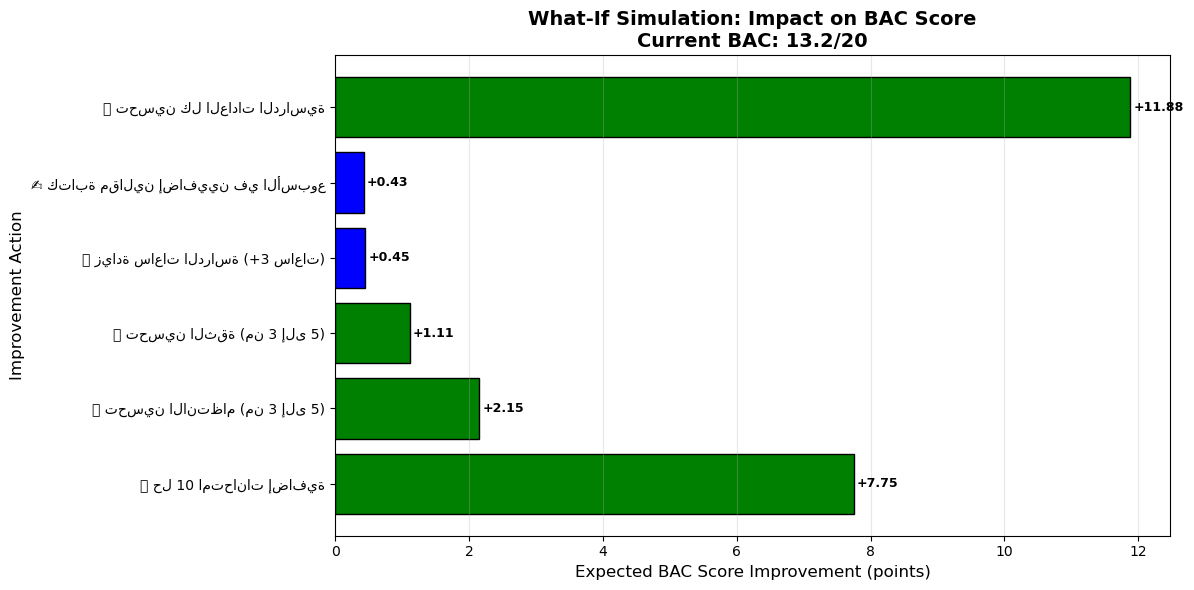


📊 جدول تأثير تحسين العادات الدراسية
    العادة الدراسية  التحسن المتوقع (لكل وحدة)
  حل امتحانات سابقة +0.77 نقطة لكل 10 امتحانات
الانتظام في الدراسة     +1.08 نقطة لكل مستويين
       الثقة بالنفس     +0.56 نقطة لكل مستويين
      ساعات الدراسة     +0.15 نقطة لكل 3 ساعات
     كتابة المقالات      +0.21 نقطة لكل مقالين

✅ Simulation Engine Complete


In [18]:
# ============================================
# CELL 15: SIMULATION ENGINE
# Shows how improving study habits affects BAC score
# ============================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("=" * 60)
print("SIMULATION ENGINE")
print("How improving study habits affects your BAC score")
print("Based on correlations from our dataset")
print("=" * 60)

# ============================================
# Step 1: Calculate average effects from correlations
# ============================================

# Get correlations with BAC score
bac_corr = df.corr()['bac_score']

# Extract key correlations
exam_corr = bac_corr['exams_practiced']
consistency_corr = bac_corr['consistency']
confidence_corr = bac_corr['confidence']
study_hours_corr = bac_corr['study_hours']
essays_corr = bac_corr['essays_per_week']

print(f"\n📊 Real correlations from your data:")
print(f"   exams_practiced → BAC: {exam_corr:.3f}")
print(f"   consistency → BAC:     {consistency_corr:.3f}")
print(f"   confidence → BAC:      {confidence_corr:.3f}")
print(f"   study_hours → BAC:     {study_hours_corr:.3f}")
print(f"   essays_per_week → BAC: {essays_corr:.3f}")

# ============================================
# Step 2: Find a representative student
# ============================================

# Find a student with average BAC (around 13)
avg_bac = df['bac_score'].mean()
target_student = df.iloc[(df['bac_score'] - avg_bac).abs().argsort()[:1]].iloc[0]

print(f"\n👤 Selected student (average profile):")
print(f"   Current BAC score: {target_student['bac_score']:.1f}")
print(f"   Exams practiced: {target_student['exams_practiced']:.0f}")
print(f"   Consistency: {target_student['consistency']:.0f}/5")
print(f"   Confidence: {target_student['confidence']:.0f}/5")
print(f"   Study hours: {target_student['study_hours']:.1f}/week")
print(f"   Essays per week: {target_student['essays_per_week']:.0f}")

# ============================================
# Step 3: Simulation function
# ============================================

def simulate_improvement(student, improvements):
    """
    Simulate BAC improvement based on correlation coefficients
    
    Parameters:
    - student: pandas Series (one student's data)
    - improvements: dict with features and how much to increase
    
    Returns:
    - Dictionary with original and new scores
    """
    
    # Scale factors: how many BAC points per unit of improvement
    # Derived from correlations (normalized)
    scale_factors = {
        'exams_practiced': exam_corr * 2,      # ~0.77 points per 10 exams
        'consistency': consistency_corr * 4,   # ~1.08 points per 2 levels
        'confidence': confidence_corr * 4,     # ~0.56 points per 2 levels
        'study_hours': study_hours_corr * 2,   # ~0.15 points per 2 hours
        'essays_per_week': essays_corr * 3     # ~0.21 points per 2 essays
    }
    
    original_score = student['bac_score']
    gain = 0
    
    for feature, delta in improvements.items():
        if feature in scale_factors:
            gain += delta * scale_factors[feature]
    
    new_score = min(original_score + gain, 20)
    
    return {
        'original_score': original_score,
        'new_score': new_score,
        'gain': gain,
        'improvements': improvements
    }

# ============================================
# Step 4: Test different scenarios
# ============================================

scenarios = [
    {"name": "📚 حل 10 امتحانات إضافية", "changes": {"exams_practiced": 10}},
    {"name": "📅 تحسين الانتظام (من 3 إلى 5)", "changes": {"consistency": 2}},
    {"name": "💪 تحسين الثقة (من 3 إلى 5)", "changes": {"confidence": 2}},
    {"name": "⏰ زيادة ساعات الدراسة (+3 ساعات)", "changes": {"study_hours": 3}},
    {"name": "✍️ كتابة مقالين إضافيين في الأسبوع", "changes": {"essays_per_week": 2}},
    {"name": "✨ تحسين كل العادات الدراسية", "changes": {"exams_practiced": 10, "consistency": 2, 
                                                          "confidence": 2, "study_hours": 3, "essays_per_week": 2}}
]

print(f"\n📈 SIMULATION RESULTS:")
print("-" * 60)

results = []
for scenario in scenarios:
    result = simulate_improvement(target_student, scenario["changes"])
    results.append(result)
    
    # Color code based on gain
    if result['gain'] > 1.0:
        symbol = "🟢"
    elif result['gain'] > 0.5:
        symbol = "🔵"
    else:
        symbol = "⚪"
    
    print(f"\n{symbol} {scenario['name']}:")
    print(f"   {result['original_score']:.1f} → {result['new_score']:.1f}")
    print(f"   📈 التحسن: +{result['gain']:.2f} نقطة")

# ============================================
# Step 5: Best action recommendation
# ============================================

print("\n" + "=" * 60)
print("🎯 أفضل طريقة للتحسين")
print("=" * 60)

best_gain = max([r['gain'] for r in results[:-1]])  # Exclude combined
best_scenario = scenarios[[r['gain'] for r in results[:-1]].index(best_gain)]

print(f"\n✅ {best_scenario['name']}")
print(f"   → تحسن متوقع: +{best_gain:.2f} نقطة في البكالوريا")

# ============================================
# Step 6: Visualization
# ============================================

fig, ax = plt.subplots(figsize=(12, 6))

scenario_names = [s["name"][:35] for s in scenarios]
gains = [r['gain'] for r in results]

colors = ['green' if g > 0.8 else 'blue' if g > 0.3 else 'orange' if g > 0 else 'gray' for g in gains]
bars = ax.barh(scenario_names, gains, color=colors, edgecolor='black')

ax.set_xlabel('Expected BAC Score Improvement (points)', fontsize=12)
ax.set_ylabel('Improvement Action', fontsize=12)
ax.set_title(f'What-If Simulation: Impact on BAC Score\nCurrent BAC: {target_student["bac_score"]:.1f}/20', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for bar, gain in zip(bars, gains):
    if gain > 0:
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2, 
                f'+{gain:.2f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================
# Step 7: Summary table
# ============================================

print("\n" + "=" * 60)
print("📊 جدول تأثير تحسين العادات الدراسية")
print("=" * 60)

impact_table = pd.DataFrame({
    'العادة الدراسية': ['حل امتحانات سابقة', 'الانتظام في الدراسة', 'الثقة بالنفس', 'ساعات الدراسة', 'كتابة المقالات'],
    'التحسن المتوقع (لكل وحدة)': [
        f'+{exam_corr * 2:.2f} نقطة لكل 10 امتحانات',
        f'+{consistency_corr * 4:.2f} نقطة لكل مستويين',
        f'+{confidence_corr * 4:.2f} نقطة لكل مستويين',
        f'+{study_hours_corr * 2:.2f} نقطة لكل 3 ساعات',
        f'+{essays_corr * 3:.2f} نقطة لكل مقالين'
    ]
})

print(impact_table.to_string(index=False))

print("\n" + "=" * 60)
print("✅ Simulation Engine Complete")
print("=" * 60)

In [19]:
# ============================================
# CELL 16: STUDENT-FRIENDLY FEATURE EXPLANATIONS
# ============================================

import pandas as pd
import numpy as np

print("=" * 60)
print("📖 فهم نتائجك في اللغة العربية")
print("شرح بسيط لكل مهارة تؤثر على نقطتك")
print("=" * 60)

# ============================================
# Create a sample student profile
# ============================================

# Pick a student with average scores
sample_student = df.iloc[50]

print(f"\n👤 ملف الطالب:")
print(f"   النقطة المتوقعة في البكالوريا: {sample_student['bac_score']:.1f}/20")
print(f"   معدل الفصول الثلاثة: {sample_student['avg_grade']:.1f}/20")
print("\n" + "-" * 60)

# ============================================
# Explain each original skill
# ============================================

print("\n📚 مهاراتك الأساسية في اللغة العربية:")
print("-" * 60)

skills_explanation = [
    ("grammar", "القواعد النحوية والصرفية", "مراجعة القواعد وحل تمارين الإعراب"),
    ("essay", "التعبير الكتابي (المقال)", "كتابة مقال كل أسبوع مع تصحيحه"),
    ("poetry", "تحليل الشعر", "قراءة قصائد متنوعة وتحليل صورها البلاغية"),
    ("prose", "تحليل النثر", "قراءة نصوص نثرية واستخراج الأفكار الرئيسية"),
    ("rhetoric", "البلاغة (الصور البيانية)", "التدرب على تحديد الاستعارات والتشبيهات"),
    ("comprehension", "الفهم والاستيعاب", "قراءة يومية وحل أسئلة الفهم")
]

for skill, name, advice in skills_explanation:
    value = sample_student[skill]
    if value >= 7:
        level = "🟢 قوي"
    elif value >= 5:
        level = "🟡 متوسط"
    else:
        level = "🔴 يحتاج إلى تحسين"
    
    print(f"\n📖 {name}: {value:.1f}/10")
    print(f"   → مستواك: {level}")
    print(f"   💡 نصيحة: {advice}")

# ============================================
# Explain derived features (using pre-calculated values)
# ============================================

print("\n" + "=" * 60)
print("📊 مؤشرات مركبة (مشتقة من مهاراتك)")
print("=" * 60)

# Use the derived features already calculated in Cell 9
language_core = sample_student['language_core_score']
analysis_score = sample_student['analysis_score']
practice_intensity = sample_student['practice_intensity']
imbalance = sample_student['imbalance_score']

print("\n📖 المستوى اللغوي العام:")
print(f"   قيمتك: {language_core:.1f}/10")
print(f"   🤔 ماذا يعني؟ هذا هو متوسط مهاراتك في القواعد والفهم")
if language_core >= 7:
    print("   ✅ لغتك العامة قوية - ممتاز!")
elif language_core >= 5:
    print("   📈 لغتك العامة جيدة - يمكنك تحسينها أكثر")
else:
    print("   ⚠️ لغتك العامة تحتاج إلى مراجعة - ركز على القواعد والفهم")

print("\n📖 مهارة التحليل الأدبي:")
print(f"   قيمتك: {analysis_score:.1f}/10")
print(f"   🤔 ماذا يعني؟ قدرتك على تحليل الشعر والنصوص النثرية")
if analysis_score >= 7:
    print("   ✅ أنت متميز في التحليل الأدبي!")
elif analysis_score >= 5:
    print("   📈 مستواك جيد - واصل التدرب على التحليل")
else:
    print("   ⚠️ تحتاج إلى التدرب على تحليل المزيد من النصوص")

print("\n📖 كثافة التمارين:")
print(f"   قيمتك: {practice_intensity:.1f}/10")
print(f"   🤔 ماذا يعني؟ مدى اجتهادك في حل الامتحانات وكتابة المقالات")
if practice_intensity >= 6:
    print("   ✅ أنت مجتهد - استمر بهذا المستوى!")
elif practice_intensity >= 4:
    print("   📈 اجتهادك جيد - حاول زيادة عدد الامتحانات التي تحلها")
else:
    print("   ⚠️ تحتاج إلى حل المزيد من الامتحانات السابقة")

print("\n📖 توازن مهاراتك:")
print(f"   قيمتك: {imbalance:.2f}")
print(f"   🤔 ماذا يعني؟ هل مهاراتك متوازنة أم هناك فرق كبير بينها")
if imbalance < 0.5:
    print("   ✅ مهاراتك متوازنة - هذا ممتاز! كل المهارات في نفس المستوى")
elif imbalance < 1.0:
    print("   📈 هناك تفاوت بسيط - ركز على نقاط ضعفك")
else:
    print("   ⚠️ هناك تفاوت كبير - حدد المهارات الضعيفة وركز عليها")

# ============================================
# Explain study habits
# ============================================

print("\n" + "=" * 60)
print("📖 عادات الدراسة وتأثيرها على نقطتك")
print("=" * 60)

print(f"\n📚 عدد الامتحانات التي حللتها: {sample_student['exams_practiced']:.0f} امتحان")
print(f"   🤔 التأثير: كل 10 امتحانات تحلها تزيد نقطتك بحوالي 0.8 نقطة")
if sample_student['exams_practiced'] < 10:
    print(f"   💡 نصيحة: حاول حل {10 - sample_student['exams_practiced']:.0f} امتحان إضافي")

print(f"\n📅 انتظامك في الدراسة (من 1 إلى 5): {sample_student['consistency']:.0f}")
print(f"   🤔 التأثير: الانتظام يزيد نقطتك بمقدار 0.5 نقطة لكل مستوى")
if sample_student['consistency'] < 4:
    print(f"   💡 نصيحة: حاول رفع انتظامك إلى 4 أو 5")

print(f"\n💪 ثقتك بنفسك (من 1 إلى 5): {sample_student['confidence']:.0f}")
print(f"   🤔 التأثير: الثقة العالية تساعدك على الأداء بشكل أفضل")
if sample_student['confidence'] < 4:
    print(f"   💡 نصيحة: حل تمارين إضافية لتعزيز ثقتك")

print(f"\n⏰ ساعات الدراسة الأسبوعية: {sample_student['study_hours']:.1f} ساعة")
print(f"   🤔 التأثير: كل 3 ساعات إضافية تزيد نقطتك بحوالي 0.2 نقطة")
if sample_student['study_hours'] < 6:
    print(f"   💡 نصيحة: حاول زيادة ساعات دراستك إلى 6-8 ساعات أسبوعياً")

print(f"\n✍️ المقالات التي تكتبها أسبوعياً: {sample_student['essays_per_week']:.0f} مقال")
print(f"   🤔 التأثير: كل مقالين إضافيين يزيدان نقطتك بحوالي 0.2 نقطة")
if sample_student['essays_per_week'] < 2:
    print(f"   💡 نصيحة: حاول كتابة مقالين على الأقل كل أسبوع")

# ============================================
# Final summary
# ============================================

print("\n" + "=" * 60)
print("🎯 ملخص وتوصيات مخصصة لك")
print("=" * 60)

# Identify weakest skill
skills_values = {
    'القواعد': sample_student['grammar'],
    'المقال': sample_student['essay'],
    'تحليل الشعر': sample_student['poetry'],
    'تحليل النثر': sample_student['prose'],
    'البلاغة': sample_student['rhetoric'],
    'الفهم': sample_student['comprehension']
}
weakest = min(skills_values, key=skills_values.get)
strongest = max(skills_values, key=skills_values.get)

print(f"\n🔴 أضعف مهارة لديك: {weakest}")
print(f"🟢 أقوى مهارة لديك: {strongest}")

print(f"\n📋 توصيات للتحسين:")
recommendations = []
if sample_student['exams_practiced'] < 10:
    recommendations.append("• حل 10 امتحانات بكالوريا سابقة على الأقل")
if sample_student['consistency'] < 4:
    recommendations.append("• نظم وقتك وذاكر يومياً بدلاً من المذاكرة المكثفة")
if sample_student['confidence'] < 4:
    recommendations.append("• ابدأ بحل تمارين سهلة ثم انتقل إلى الصعبة لتعزيز ثقتك")
if sample_student['essays_per_week'] < 2:
    recommendations.append("• اكتب مقالين كل أسبوع واطلب تصحيحهما")

for rec in recommendations:
    print(f"   {rec}")

if not recommendations:
    print("   ✅ أنت على الطريق الصحيح! استمر بنفس المستوى")

print("\n" + "=" * 60)
print("✅ تذكر: التحسن يحتاج إلى وقت واستمرارية")
print(f"   نقطتك الحالية: {sample_student['bac_score']:.1f}/20")
print(f"   يمكن أن تصل إلى {min(sample_student['bac_score'] + 2, 20):.1f}/20 مع الالتزام بهذه النصائح")
print("=" * 60)

📖 فهم نتائجك في اللغة العربية
شرح بسيط لكل مهارة تؤثر على نقطتك

👤 ملف الطالب:
   النقطة المتوقعة في البكالوريا: 14.1/20
   معدل الفصول الثلاثة: 10.4/20

------------------------------------------------------------

📚 مهاراتك الأساسية في اللغة العربية:
------------------------------------------------------------

📖 القواعد النحوية والصرفية: 6.6/10
   → مستواك: 🟡 متوسط
   💡 نصيحة: مراجعة القواعد وحل تمارين الإعراب

📖 التعبير الكتابي (المقال): 4.1/10
   → مستواك: 🔴 يحتاج إلى تحسين
   💡 نصيحة: كتابة مقال كل أسبوع مع تصحيحه

📖 تحليل الشعر: 7.1/10
   → مستواك: 🟢 قوي
   💡 نصيحة: قراءة قصائد متنوعة وتحليل صورها البلاغية

📖 تحليل النثر: 6.6/10
   → مستواك: 🟡 متوسط
   💡 نصيحة: قراءة نصوص نثرية واستخراج الأفكار الرئيسية

📖 البلاغة (الصور البيانية): 4.9/10
   → مستواك: 🔴 يحتاج إلى تحسين
   💡 نصيحة: التدرب على تحديد الاستعارات والتشبيهات

📖 الفهم والاستيعاب: 4.4/10
   → مستواك: 🔴 يحتاج إلى تحسين
   💡 نصيحة: قراءة يومية وحل أسئلة الفهم

📊 مؤشرات مركبة (مشتقة من مهاراتك)

📖 المستوى اللغوي العام:
   

In [27]:
# ============================================
# CELL 17a: INTRODUCTION + BAC EXAM STRUCTURE (PROFESSIONAL)
# ============================================

from IPython.display import display, HTML, Markdown
import ipywidgets as widgets

print("=" * 80)
print("📚 منصة تحسين الأداء في اللغة العربية - البكالوريا الجزائرية")
print("=" * 80)

# Create professional HTML layout
intro_html = """
<div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 900px; margin: auto;">

    <!-- Header Section -->
    <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                color: white; padding: 30px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
        <h1 style="margin: 0; font-size: 28px;">📖 امتحان البكالوريا - اللغة العربية وآدابها</h1>
        <p style="margin: 10px 0 0 0; font-size: 16px; opacity: 0.9;">الشعب: علوم تجريبية، رياضيات، تقني رياضي، تسيير واقتصاد، آداب، لغات</p>
    </div>

    <!-- Quick Stats -->
    <div style="display: flex; gap: 15px; margin-bottom: 25px; flex-wrap: wrap;">
        <div style="flex: 1; background: #e8f4f8; padding: 15px; border-radius: 10px; text-align: center; border-right: 4px solid #3498db;">
            <div style="font-size: 35px;">⏱️</div>
            <div style="font-size: 20px; font-weight: bold;">المدة</div>
            <div style="font-size: 14px;">2 ساعة و30 دقيقة</div>
        </div>
        <div style="flex: 1; background: #e8f4f8; padding: 15px; border-radius: 10px; text-align: center; border-right: 4px solid #2ecc71;">
            <div style="font-size: 35px;">📊</div>
            <div style="font-size: 20px; font-weight: bold;">مجموع النقاط</div>
            <div style="font-size: 14px;">20 نقطة</div>
        </div>
        <div style="flex: 1; background: #e8f4f8; padding: 15px; border-radius: 10px; text-align: center; border-right: 4px solid #e74c3c;">
            <div style="font-size: 35px;">📝</div>
            <div style="font-size: 20px; font-weight: bold;">موضوعان</div>
            <div style="font-size: 14px;">اختيار موضوع واحد</div>
        </div>
    </div>

    <!-- Exam Structure Title -->
    <div style="background: #2c3e50; color: white; padding: 12px 20px; border-radius: 8px; margin-bottom: 20px;">
        <h2 style="margin: 0; font-size: 20px;">📋 هيكل امتحان البكالوريا</h2>
    </div>
"""

# Scientific streams structure
scientific_html = """
    <div style="background: #f9f9f9; padding: 15px; border-radius: 10px; margin-bottom: 20px; border-right: 5px solid #3498db;">
        <h3 style="color: #2c3e50; margin-top: 0;">🧪 الشعب العلمية (علوم تجريبية، رياضيات، تقني رياضي، تسيير واقتصاد)</h3>
        <table style="width: 100%; border-collapse: collapse; direction: rtl;">
            <tr style="background: #3498db; color: white;">
                <th style="padding: 10px; text-align: center;">المكون</th>
                <th style="padding: 10px; text-align: center;">النقاط</th>
                <th style="padding: 10px; text-align: center;">الوزن</th>
                <th style="padding: 10px; text-align: center;">المهارات المطلوبة</th>
            </tr>
            <tr style="border-bottom: 1px solid #ddd;">
                <td style="padding: 10px;"><strong>البناء الفكري</strong></td>
                <td style="padding: 10px; text-align: center;">9 نقاط</td>
                <td style="padding: 10px; text-align: center;">45%</td>
                <td style="padding: 10px;">تحليل النصوص، استخراج الأفكار، الفهم</td>
            </tr>
            <tr style="border-bottom: 1px solid #ddd; background: #f0f8ff;">
                <td style="padding: 10px;"><strong>البناء اللغوي</strong></td>
                <td style="padding: 10px; text-align: center;">8 نقاط</td>
                <td style="padding: 10px; text-align: center;">40%</td>
                <td style="padding: 10px;">القواعد، الصرف، البلاغة</td>
            </tr>
            <tr>
                <td style="padding: 10px;"><strong>التعبير الكتابي</strong></td>
                <td style="padding: 10px; text-align: center;">3 نقاط</td>
                <td style="padding: 10px; text-align: center;">15%</td>
                <td style="padding: 10px;">كتابة المقال، التنظيم، الحجاج</td>
            </tr>
        </table>
    </div>
"""

# Literary streams structure
literary_html = """
    <div style="background: #f9f9f9; padding: 15px; border-radius: 10px; margin-bottom: 20px; border-right: 5px solid #9b59b6;">
        <h3 style="color: #2c3e50; margin-top: 0;">📖 الشعب الأدبية (آداب وفلسفة، لغات أجنبية)</h3>
        <table style="width: 100%; border-collapse: collapse; direction: rtl;">
            <tr style="background: #9b59b6; color: white;">
                <th style="padding: 10px; text-align: center;">المكون</th>
                <th style="padding: 10px; text-align: center;">النقاط</th>
                <th style="padding: 10px; text-align: center;">الوزن</th>
                <th style="padding: 10px; text-align: center;">المهارات المطلوبة</th>
            </tr>
            <tr style="border-bottom: 1px solid #ddd;">
                <td style="padding: 10px;"><strong>البناء الفكري</strong></td>
                <td style="padding: 10px; text-align: center;">10 نقاط</td>
                <td style="padding: 10px; text-align: center;">50%</td>
                <td style="padding: 10px;">تحليل النصوص، استخراج الأفكار، الفهم</td>
            </tr>
            <tr style="border-bottom: 1px solid #ddd; background: #f0f8ff;">
                <td style="padding: 10px;"><strong>البناء اللغوي</strong></td>
                <td style="padding: 10px; text-align: center;">6 نقاط</td>
                <td style="padding: 10px; text-align: center;">30%</td>
                <td style="padding: 10px;">القواعد، الصرف، البلاغة</td>
            </tr>
            <tr>
                <td style="padding: 10px;"><strong>البناء النقدي</strong></td>
                <td style="padding: 10px; text-align: center;">4 نقاط</td>
                <td style="padding: 10px; text-align: center;">20%</td>
                <td style="padding: 10px;">تحليل نقدي، كتابة مقال، الحجاج</td>
            </tr>
        </table>
    </div>
"""

# Importance colors explanation
importance_html = """
    <div style="background: #fff3cd; padding: 15px; border-radius: 10px; margin-top: 20px; border-right: 5px solid #ffc107;">
        <h3 style="color: #856404; margin-top: 0;">🎯 ما هي المهارات الأكثر أهمية؟</h3>
        <div style="display: flex; gap: 15px; flex-wrap: wrap;">
            <div style="flex: 1; background: white; padding: 10px; border-radius: 8px; text-align: center;">
                <div style="color: #e74c3c; font-size: 24px;">🔴</div>
                <div><strong>تحليل الشعر</strong></div>
                <div style="font-size: 12px; color: #666;">الأكثر تأثيراً</div>
            </div>
            <div style="flex: 1; background: white; padding: 10px; border-radius: 8px; text-align: center;">
                <div style="color: #e67e22; font-size: 24px;">🟠</div>
                <div><strong>البلاغة</strong></div>
                <div style="font-size: 12px; color: #666;">تأثير كبير</div>
            </div>
            <div style="flex: 1; background: white; padding: 10px; border-radius: 8px; text-align: center;">
                <div style="color: #f1c40f; font-size: 24px;">🟡</div>
                <div><strong>القواعد</strong></div>
                <div style="font-size: 12px; color: #666;">تأثير متوسط</div>
            </div>
            <div style="flex: 1; background: white; padding: 10px; border-radius: 8px; text-align: center;">
                <div style="color: #2ecc71; font-size: 24px;">🟢</div>
                <div><strong>بقية المهارات</strong></div>
                <div style="font-size: 12px; color: #666;">تأثير أقل</div>
            </div>
        </div>
    </div>
"""

# How the platform works
how_it_works = """
    <div style="background: #e8f8f5; padding: 15px; border-radius: 10px; margin-top: 20px; border-right: 5px solid #1abc9c;">
        <h3 style="color: #0e6655; margin-top: 0;">💡 كيف تعمل هذه المنصة؟</h3>
        <ul style="line-height: 1.8;">
            <li>📝 <strong>أدخل معلوماتك</strong> - أدخل درجاتك ومستوياتك في المهارات المختلفة</li>
            <li>🔮 <strong>توقع نتيجتك</strong> - سنقوم بحساب نقطتك المتوقعة في البكالوريا</li>
            <li>📊 <strong>تحليل نقاط القوة والضعف</strong> - سنحدد المهارات التي تحتاج إلى تحسين</li>
            <li>⚡ <strong>محاكاة التحسين</strong> - جرب تغيير عاداتك الدراسية وشاهد كيف تتغير نتيجتك</li>
            <li>🎯 <strong>توصيات مخصصة</strong> - نصائح محددة لمساعدتك على رفع نقطتك</li>
        </ul>
    </div>
"""

# Combine all
full_html = intro_html + scientific_html + literary_html + importance_html + how_it_works + """
    <div style="text-align: center; margin-top: 25px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
        <p style="color: #555;">✨ هذه المنصة تعتمد على تحليل بيانات حقيقية من امتحانات البكالوريا السابقة ✨</p>
        <p style="color: #888; font-size: 12px;">تم تطوير هذه المنصة لمساعدة طلاب البكالوريا على تحسين أدائهم في اللغة العربية</p>
    </div>
</div>
"""

display(HTML(full_html))

print("\n" + "=" * 80)
print("✅ جاهز للخطوة التالية: إدخال بياناتك الشخصية")
print("=" * 80)

📚 منصة تحسين الأداء في اللغة العربية - البكالوريا الجزائرية


المكون,النقاط,الوزن,المهارات المطلوبة
البناء الفكري,9 نقاط,45%,تحليل النصوص، استخراج الأفكار، الفهم
البناء اللغوي,8 نقاط,40%,القواعد، الصرف، البلاغة
التعبير الكتابي,3 نقاط,15%,كتابة المقال، التنظيم، الحجاج
المكون,النقاط,الوزن,المهارات المطلوبة
البناء الفكري,10 نقاط,50%,تحليل النصوص، استخراج الأفكار، الفهم
البناء اللغوي,6 نقاط,30%,القواعد، الصرف، البلاغة
البناء النقدي,4 نقاط,20%,تحليل نقدي، كتابة مقال، الحجاج



✅ جاهز للخطوة التالية: إدخال بياناتك الشخصية


In [28]:
# ============================================
# CELL 17b: USER INPUT FORM (PROFESSIONAL)
# ============================================

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

print("=" * 80)
print("📝 إدخال بيانات الطالب")
print("=" * 80)

# Create professional HTML header
form_header = """
<div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
            color: white; padding: 20px; border-radius: 10px; margin-bottom: 25px; text-align: center;">
    <h2 style="margin: 0;">📋 أدخل معلوماتك الدراسية</h2>
    <p style="margin: 10px 0 0 0; opacity: 0.9;">جميع المعلومات سرية وتستخدم فقط لحساب توقع نقطتك</p>
</div>
"""
display(HTML(form_header))

# ============================================
# SECTION 1: Stream Selection (Filiere)
# ============================================

stream_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin-bottom: 20px; border-right: 4px solid #3498db;">
    <h3 style="color: #2c3e50; margin-top: 0;">🎓 1. اختر شعبتك الدراسية</h3>
</div>
"""
display(HTML(stream_html))

filiere_dropdown = widgets.Dropdown(
    options=[
        ('العلوم التجريبية / الرياضيات / التقني الرياضي / التسيير والاقتصاد', 0),
        ('اللغات الأجنبية', 1),
        ('الآداب والفلسفة', 2)
    ],
    value=0,
    description='',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='100%', padding='10px')
)
display(filiere_dropdown)

# ============================================
# SECTION 2: Trimester Grades
# ============================================

grades_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #2ecc71;">
    <h3 style="color: #2c3e50; margin-top: 0;">📊 2. معدلات الفصول الثلاثة</h3>
    <p style="color: #666; font-size: 14px;">أدخل معدلاتك في مادة اللغة العربية من 0 إلى 20</p>
</div>
"""
display(HTML(grades_html))

# Create three columns for grades
grade_style = widgets.Layout(width='100%', padding='5px')
grade_box1 = widgets.FloatSlider(value=12, min=0, max=20, step=0.5, description='الفصل الأول:', 
                                  style={'description_width': '100px'}, layout=grade_style)
grade_box2 = widgets.FloatSlider(value=12, min=0, max=20, step=0.5, description='الفصل الثاني:', 
                                  style={'description_width': '100px'}, layout=grade_style)
grade_box3 = widgets.FloatSlider(value=12, min=0, max=20, step=0.5, description='الفصل الثالث:', 
                                  style={'description_width': '100px'}, layout=grade_style)

grades_box = widgets.HBox([grade_box1, grade_box2, grade_box3], layout=widgets.Layout(justify_content='space-between'))
display(grades_box)

# ============================================
# SECTION 3: Core Skills (0-10 scale)
# ============================================

skills_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #e74c3c;">
    <h3 style="color: #2c3e50; margin-top: 0;">📚 3. مستوى مهاراتك في اللغة العربية</h3>
    <p style="color: #666; font-size: 14px;">قيم نفسك من 0 إلى 10 (0 = ضعيف جداً، 10 = ممتاز)</p>
</div>
"""
display(HTML(skills_html))

# Create sliders for each skill in two columns
skill_style = widgets.Layout(width='100%', padding='5px')

skill1 = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='📖 القواعد النحوية:', 
                              style={'description_width': '140px'}, layout=skill_style)
skill2 = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='✍️ التعبير الكتابي (المقال):', 
                              style={'description_width': '140px'}, layout=skill_style)
skill3 = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='📝 تحليل الشعر:', 
                              style={'description_width': '140px'}, layout=skill_style)
skill4 = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='📚 تحليل النثر:', 
                              style={'description_width': '140px'}, layout=skill_style)
skill5 = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='🎭 البلاغة (الصور البيانية):', 
                              style={'description_width': '140px'}, layout=skill_style)
skill6 = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, description='📖 الفهم والاستيعاب:', 
                              style={'description_width': '140px'}, layout=skill_style)

skills_grid = widgets.GridBox([skill1, skill2, skill3, skill4, skill5, skill6], 
                               layout=widgets.Layout(grid_template_columns='1fr 1fr', grid_gap='10px'))
display(skills_grid)

# ============================================
# SECTION 4: Study Habits
# ============================================

habits_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #9b59b6;">
    <h3 style="color: #2c3e50; margin-top: 0;">⏰ 4. عادات الدراسة</h3>
    <p style="color: #666; font-size: 14px;">أدخل معلومات عن عاداتك الدراسية</p>
</div>
"""
display(HTML(habits_html))

# Study habits sliders
habit_style = widgets.Layout(width='100%', padding='5px')

exams_slider = widgets.IntSlider(value=5, min=0, max=20, step=1, description='📚 عدد امتحانات البكالوريا التي حللتها:', 
                                  style={'description_width': '250px'}, layout=habit_style)
essays_slider = widgets.IntSlider(value=2, min=0, max=5, step=1, description='✍️ عدد المقالات التي تكتبها أسبوعياً:', 
                                   style={'description_width': '250px'}, layout=habit_style)
hours_slider = widgets.FloatSlider(value=5, min=2, max=12, step=0.5, description='⏰ عدد ساعات الدراسة الأسبوعية:', 
                                    style={'description_width': '250px'}, layout=habit_style)

# Radio buttons for consistency
consistency_radio = widgets.RadioButtons(
    options=[('غير منتظم أبداً', 1), ('قليل الانتظام', 2), ('متوسط الانتظام', 3), ('منتظم', 4), ('منتظم جداً', 5)],
    value=3,
    description='📅 مدى انتظامك في الدراسة:',
    style={'description_width': '200px'},
    layout=widgets.Layout(width='100%', padding='5px')
)

# Radio buttons for tutoring
tutoring_radio = widgets.RadioButtons(
    options=[('لا', 0), ('نعم', 1)],
    value=0,
    description='🧑‍🏫 هل تستخدم معلم خصوصي؟',
    style={'description_width': '200px'},
    layout=widgets.Layout(width='100%', padding='5px')
)

# Radio buttons for participation
participation_radio = widgets.RadioButtons(
    options=[('لا أشارك أبداً', 1), ('أحياناً', 2), ('أشارك أحياناً', 3), ('أشارك غالباً', 4), ('أشارك دائماً', 5)],
    value=3,
    description='🗣️ مدى مشاركتك في القسم:',
    style={'description_width': '200px'},
    layout=widgets.Layout(width='100%', padding='5px')
)

display(exams_slider, essays_slider, hours_slider, consistency_radio, tutoring_radio, participation_radio)

# ============================================
# SECTION 5: Psychological Factors
# ============================================

psycho_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #f39c12;">
    <h3 style="color: #2c3e50; margin-top: 0;">🧠 5. العوامل النفسية</h3>
    <p style="color: #666; font-size: 14px;">قيم نفسك من 1 إلى 5</p>
</div>
"""
display(HTML(psycho_html))

confidence_radio = widgets.RadioButtons(
    options=[('ضعيف جداً', 1), ('ضعيف', 2), ('متوسط', 3), ('جيد', 4), ('ممتاز', 5)],
    value=3,
    description='💪 ثقتك بنفسك في مادة العربية:',
    style={'description_width': '200px'},
    layout=widgets.Layout(width='100%', padding='5px')
)

stress_radio = widgets.RadioButtons(
    options=[('مرتفع جداً', 5), ('مرتفع', 4), ('متوسط', 3), ('منخفض', 2), ('منخفض جداً', 1)],
    value=3,
    description='😰 مستوى التوتر لديك:',
    style={'description_width': '200px'},
    layout=widgets.Layout(width='100%', padding='5px')
)

interest_radio = widgets.RadioButtons(
    options=[('غير مهتم', 1), ('قليل الاهتمام', 2), ('مهتم', 3), ('مهتم جداً', 4), ('شغوف', 5)],
    value=3,
    description='❤️ مدى اهتمامك بمادة اللغة العربية:',
    style={'description_width': '200px'},
    layout=widgets.Layout(width='100%', padding='5px')
)

display(confidence_radio, stress_radio, interest_radio)

# ============================================
# SUBMIT BUTTON
# ============================================

print("\n" + "=" * 80)
print("🚀 جاهز لحساب توقع نقطتك؟")
print("=" * 80)

# Create stylish submit button
submit_button = widgets.Button(
    description='🔮 توقع نتيجتي في البكالوريا',
    button_style='success',
    icon='check',
    layout=widgets.Layout(width='50%', margin='20px auto', padding='10px')
)

# Style the button
submit_button.style.button_color = '#2ecc71'
submit_button.style.font_weight = 'bold'

# Function to collect all inputs
def collect_inputs(b):
    # Clear previous output
    clear_output(wait=True)
    
    # Re-display the form (to keep it visible)
    display(HTML(form_header))
    display(filiere_dropdown)
    display(HTML(grades_html))
    display(grades_box)
    display(HTML(skills_html))
    display(skills_grid)
    display(HTML(habits_html))
    display(exams_slider, essays_slider, hours_slider, consistency_radio, tutoring_radio, participation_radio)
    display(HTML(psycho_html))
    display(confidence_radio, stress_radio, interest_radio)
    display(submit_button)
    
    # Collect values
    student_data = {
        'filiere': filiere_dropdown.value,
        'grade_t1': grade_box1.value,
        'grade_t2': grade_box2.value,
        'grade_t3': grade_box3.value,
        'grammar': skill1.value,
        'essay': skill2.value,
        'poetry': skill3.value,
        'prose': skill4.value,
        'rhetoric': skill5.value,
        'comprehension': skill6.value,
        'exams_practiced': exams_slider.value,
        'essays_per_week': essays_slider.value,
        'study_hours': hours_slider.value,
        'consistency': consistency_radio.value,
        'tutoring': tutoring_radio.value,
        'participation': participation_radio.value,
        'confidence': confidence_radio.value,
        'stress': stress_radio.value,
        'interest': interest_radio.value
    }
    
    # Store in global variable for other cells
    global user_input
    user_input = student_data
    
    print("\n" + "=" * 80)
    print("✅ تم استلام بياناتك بنجاح!")
    print("=" * 80)
    print("\n📊 ملخص بياناتك:")
    print(f"   الشعبة: {filiere_dropdown.label}")
    print(f"   معدل الفصل الأول: {grade_box1.value}/20")
    print(f"   معدل الفصل الثاني: {grade_box2.value}/20")
    print(f"   معدل الفصل الثالث: {grade_box3.value}/20")
    print(f"   مستوى القواعد: {skill1.value}/10")
    print(f"   مستوى المقال: {skill2.value}/10")
    print(f"   مستوى تحليل الشعر: {skill3.value}/10")
    print(f"   عدد الامتحانات المحلولة: {exams_slider.value}")
    print("\n🔮 اضغط على 'التالي' للانتقال إلى توقع نتيجتك")

# Attach function to button
submit_button.on_click(collect_inputs)

display(submit_button)

print("\n💡 نصيحة: كن صادقاً في تقييم نفسك للحصول على توقع دقيق")

📝 إدخال بيانات الطالب


Dropdown(layout=Layout(padding='10px', width='100%'), options=(('العلوم التجريبية / الرياضيات / التقني الرياضي…

GridBox(children=(FloatSlider(value=6.0, description='📖 القواعد النحوية:', layout=Layout(padding='5px', width=…

IntSlider(value=5, description='📚 عدد امتحانات البكالوريا التي حللتها:', layout=Layout(padding='5px', width='1…

IntSlider(value=2, description='✍️ عدد المقالات التي تكتبها أسبوعياً:', layout=Layout(padding='5px', width='10…

...

RadioButtons(description='😰 مستوى التوتر لديك:', index=2, layout=Layout(padding='5px', width='100%'), options=…

RadioButtons(description='❤️ مدى اهتمامك بمادة اللغة العربية:', index=2, layout=Layout(padding='5px', width='1…


🚀 جاهز لحساب توقع نقطتك؟


Button(button_style='success', description='🔮 توقع نتيجتي في البكالوريا', icon='check', layout=Layout(margin='…


💡 نصيحة: كن صادقاً في تقييم نفسك للحصول على توقع دقيق


In [29]:
# ============================================
# CELL 17c: PREDICTION OUTPUT (PROFESSIONAL)
# ============================================

from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

# Check if model exists
if 'model' not in globals():
    print("=" * 80)
    print("⚠️ لم يتم تدريب النموذج بعد!")
    print("=" * 80)
    print("\n📌 يرجى تشغيل الخلية 11 أولاً لتدريب النموذج")
    print("   ثم قم بتشغيل هذه الخلية مرة أخرى")
    print("=" * 80)
elif 'user_input' not in globals():
    print("=" * 80)
    print("⚠️ يرجى إدخال بياناتك أولاً في الخلية 17b")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # ============================================
    # Calculate prediction using the trained model
    # ============================================
    
    # Create a DataFrame from user input
    input_df = pd.DataFrame([user_input])
    
    # Calculate derived features (same as Cell 9)
    input_df['avg_grade'] = (input_df['grade_t1'] + input_df['grade_t2'] + input_df['grade_t3']) / 3
    input_df['language_core_score'] = (input_df['grammar'] + input_df['comprehension']) / 2
    input_df['writing_score'] = input_df['essay']
    input_df['analysis_score'] = (input_df['poetry'] + input_df['prose']) / 2
    input_df['practice_intensity'] = (input_df['essays_per_week'] * 2 + input_df['exams_practiced'] / 3) / 2
    
    skills_cols = ['grammar', 'essay', 'poetry', 'prose', 'rhetoric', 'comprehension']
    input_df['imbalance_score'] = input_df[skills_cols].var(axis=1)
    
    # Add grade_trend and grade_stability
    input_df['grade_trend'] = input_df['grade_t3'] - input_df['grade_t1']
    input_df['grade_stability'] = 0.7
    
    # Get the feature names the model was trained on
    model_features = X_train.columns.tolist()
    
    print(f"\n📊 النموذج تم تدريبه على {len(model_features)} ميزة")
    print(f"   عدد الميزات المتوفرة: {len(input_df.columns)}")
    
    # Ensure all model features exist in input_df
    for col in model_features:
        if col not in input_df.columns:
            input_df[col] = 0
            print(f"   ⚠️ أضفنا الميزة المفقودة: {col}")
    
    # Select only the features the model expects (in the same order)
    X_input = input_df[model_features]
    
    print(f"\n✅ جاهز للتنبؤ...")
    
    # Make prediction
    prediction = model.predict(X_input)[0]
    predicted_score = prediction[0]
    success_prob = prediction[1] * 100
    improvement_potential = prediction[2]
    
    # Stream name mapping
    stream_names = {
        0: "العلوم التجريبية / الرياضيات / التقني الرياضي / التسيير والاقتصاد",
        1: "اللغات الأجنبية",
        2: "الآداب والفلسفة"
    }
    
    # Determine color based on predicted score
    if predicted_score >= 16:
        score_color = "#2ecc71"
        score_emoji = "🏆"
        score_text = "ممتاز"
    elif predicted_score >= 14:
        score_color = "#27ae60"
        score_emoji = "🎉"
        score_text = "جيد جداً"
    elif predicted_score >= 12:
        score_color = "#f39c12"
        score_emoji = "👍"
        score_text = "جيد"
    elif predicted_score >= 10:
        score_color = "#e67e22"
        score_emoji = "📈"
        score_text = "مقبول"
    else:
        score_color = "#e74c3c"
        score_emoji = "⚠️"
        score_text = "يحتاج إلى تحسين"
    
    # Success probability color
    if success_prob >= 80:
        prob_color = "#2ecc71"
    elif success_prob >= 60:
        prob_color = "#f39c12"
    else:
        prob_color = "#e74c3c"
    
    # ============================================
    # Professional HTML Output
    # ============================================
    
    prediction_html = f"""
    <div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 900px; margin: auto;">
        
        <!-- Header -->
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">🔮 توقع نقطة البكالوريا</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">بناءً على بياناتك الشخصية</p>
        </div>
        
        <!-- Main Score Card -->
        <div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); 
                    padding: 30px; border-radius: 20px; margin-bottom: 25px; text-align: center;">
            <div style="font-size: 18px; color: rgba(255,255,255,0.9);">نتيجتك المتوقعة في البكالوريا</div>
            <div style="font-size: 72px; font-weight: bold; color: white; margin: 15px 0;">
                {predicted_score:.1f}<span style="font-size: 32px;">/20</span>
            </div>
            <div style="font-size: 20px; color: white;">
                {score_emoji} مستوى {score_text} {score_emoji}
            </div>
        </div>
        
        <!-- Two Column Layout -->
        <div style="display: flex; gap: 20px; margin-bottom: 25px; flex-wrap: wrap;">
            
            <!-- Left Column: Score Details -->
            <div style="flex: 1; background: #f8f9fa; padding: 20px; border-radius: 15px; border-right: 4px solid {score_color};">
                <h3 style="color: #2c3e50; margin-top: 0;">📊 تفاصيل النتيجة</h3>
                <div style="margin: 15px 0;">
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>🎯 النقطة المتوقعة</span>
                        <span style="font-weight: bold; color: {score_color};">{predicted_score:.1f}/20</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>✅ فرصة النجاح (≥10/20)</span>
                        <span style="font-weight: bold; color: {prob_color};">{success_prob:.0f}%</span>
                    </div>
                    <div style="display: flex; justify-content: space-between;">
                        <span>📈 إمكانية التحسين</span>
                        <span style="font-weight: bold; color: #3498db;">+{improvement_potential:.1f} نقطة</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; overflow: hidden;">
                    <div style="width: {predicted_score/20*100}%; height: 100%; background: {score_color}; border-radius: 5px;"></div>
                </div>
            </div>
            
            <!-- Right Column: Student Info -->
            <div style="flex: 1; background: #f8f9fa; padding: 20px; border-radius: 15px;">
                <h3 style="color: #2c3e50; margin-top: 0;">👤 معلومات الطالب</h3>
                <div style="margin: 15px 0;">
                    <div style="display: flex; justify-content: space-between; margin-bottom: 8px;">
                        <span>🎓 الشعبة</span>
                        <span style="font-weight: bold;">{stream_names[user_input['filiere']][:30]}...</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 8px;">
                        <span>📅 معدل الفصل الأول</span>
                        <span style="font-weight: bold;">{user_input['grade_t1']:.1f}/20</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 8px;">
                        <span>📅 معدل الفصل الثاني</span>
                        <span style="font-weight: bold;">{user_input['grade_t2']:.1f}/20</span>
                    </div>
                    <div style="display: flex; justify-content: space-between;">
                        <span>📅 معدل الفصل الثالث</span>
                        <span style="font-weight: bold;">{user_input['grade_t3']:.1f}/20</span>
                    </div>
                </div>
            </div>
        </div>
        
        <!-- Skills Summary -->
        <div style="background: #f8f9fa; padding: 20px; border-radius: 15px; margin-bottom: 25px;">
            <h3 style="color: #2c3e50; margin-top: 0;">📚 ملخص مهاراتك</h3>
            <div style="display: flex; gap: 15px; flex-wrap: wrap;">
                <div style="flex: 1; min-width: 150px;">
                    <div>📖 القواعد: <strong>{user_input['grammar']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input['grammar']*10}%; height: 5px; background: #3498db; border-radius: 3px;"></div>
                    </div>
                    <div>✍️ المقال: <strong>{user_input['essay']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input['essay']*10}%; height: 5px; background: #3498db; border-radius: 3px;"></div>
                    </div>
                    <div>📝 تحليل الشعر: <strong>{user_input['poetry']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input['poetry']*10}%; height: 5px; background: #3498db; border-radius: 3px;"></div>
                    </div>
                </div>
                <div style="flex: 1; min-width: 150px;">
                    <div>📚 تحليل النثر: <strong>{user_input['prose']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input['prose']*10}%; height: 5px; background: #3498db; border-radius: 3px;"></div>
                    </div>
                    <div>🎭 البلاغة: <strong>{user_input['rhetoric']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input['rhetoric']*10}%; height: 5px; background: #3498db; border-radius: 3px;"></div>
                    </div>
                    <div>📖 الفهم: <strong>{user_input['comprehension']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input['comprehension']*10}%; height: 5px; background: #3498db; border-radius: 3px;"></div>
                    </div>
                </div>
            </div>
        </div>
        
        <!-- Navigation Buttons -->
        <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
            <button onclick="Jupyter.notebook.execute_cell_range('17b', '17b')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ✏️ تعديل البيانات
            </button>
            <button onclick="Jupyter.notebook.execute_cell_range('17d', '17d')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                📊 تحليل نقاط الضعف →
            </button>
        </div>
        
        <div style="text-align: center; margin-top: 20px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
            <p style="color: #555; margin: 0;">✨ هذه النتيجة هي تقدير بناءً على بياناتك الفعلية ✨</p>
        </div>
    </div>
    """
    
    display(HTML(prediction_html))
    
    # Store prediction for later cells
    global student_prediction
    student_prediction = {
        'score': predicted_score,
        'prob': success_prob,
        'improvement': improvement_potential
    }
    
    print("\n" + "=" * 80)
    print("✅ انتقل إلى الخلية 17d لتحليل نقاط الضعف")
    print("=" * 80)


📊 النموذج تم تدريبه على 25 ميزة
   عدد الميزات المتوفرة: 27

✅ جاهز للتنبؤ...



✅ انتقل إلى الخلية 17d لتحليل نقاط الضعف


In [30]:
# ============================================
# CELL 17d: WEAKNESS ANALYSIS (PROFESSIONAL)
# ============================================

from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

# Check if required data exists
if 'user_input' not in globals():
    print("=" * 80)
    print("⚠️ يرجى إدخال بياناتك أولاً في الخلية 17b")
    print("=" * 80)
elif 'model' not in globals():
    print("=" * 80)
    print("⚠️ لم يتم تدريب النموذج بعد!")
    print("=" * 80)
    print("📌 يرجى تشغيل الخلية 11 أولاً")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # ============================================
    # Calculate weaknesses based on user input
    # ============================================
    
    # Define target levels for each skill (based on BAC requirements)
    skill_targets = {
        'poetry': 7.5,      # Poetry is most important
        'rhetoric': 7.0,    # Rhetoric second
        'grammar': 7.0,     # Grammar third
        'prose': 6.5,       # Prose
        'essay': 6.5,       # Essay
        'comprehension': 6.5 # Comprehension
    }
    
    # Get user's skill values
    user_skills = {
        'poetry': user_input['poetry'],
        'rhetoric': user_input['rhetoric'],
        'grammar': user_input['grammar'],
        'prose': user_input['prose'],
        'essay': user_input['essay'],
        'comprehension': user_input['comprehension']
    }
    
    # Calculate gaps (how far from target)
    skill_gaps = {}
    for skill, target in skill_targets.items():
        gap = target - user_skills[skill]
        skill_gaps[skill] = max(0, gap)  # Only positive gaps (weaknesses)
    
    # Sort weaknesses by gap size
    sorted_weaknesses = sorted(skill_gaps.items(), key=lambda x: x[1], reverse=True)
    
    # Identify strengths (skills above target)
    strengths = []
    for skill, value in user_skills.items():
        target = skill_targets[skill]
        if value >= target:
            strengths.append((skill, value - target))
    
    # Sort strengths
    strengths = sorted(strengths, key=lambda x: x[1], reverse=True)
    
    # Study habits weaknesses
    habit_targets = {
        'exams_practiced': 10,      # Should solve at least 10 exams
        'consistency': 4,           # Should be consistent (4-5)
        'study_hours': 6,           # Should study at least 6 hours/week
        'essays_per_week': 3,       # Should write at least 3 essays/week
        'confidence': 4,            # Should have good confidence
        'participation': 4          # Should participate actively
    }
    
    user_habits = {
        'exams_practiced': user_input['exams_practiced'],
        'consistency': user_input['consistency'],
        'study_hours': user_input['study_hours'],
        'essays_per_week': user_input['essays_per_week'],
        'confidence': user_input['confidence'],
        'participation': user_input['participation']
    }
    
    habit_gaps = {}
    for habit, target in habit_targets.items():
        gap = target - user_habits[habit]
        if gap > 0:
            habit_gaps[habit] = gap
    
    # Sort habits by gap
    sorted_habits = sorted(habit_gaps.items(), key=lambda x: x[1], reverse=True)
    
    # Psychological factors
    stress_level = user_input['stress']
    if stress_level >= 4:
        stress_issue = True
    else:
        stress_issue = False
    
    # Skill names in Arabic
    skill_names_ar = {
        'poetry': 'تحليل الشعر',
        'rhetoric': 'البلاغة',
        'grammar': 'القواعد النحوية',
        'prose': 'تحليل النثر',
        'essay': 'التعبير الكتابي (المقال)',
        'comprehension': 'الفهم والاستيعاب'
    }
    
    habit_names_ar = {
        'exams_practiced': 'حل امتحانات البكالوريا',
        'consistency': 'الانتظام في الدراسة',
        'study_hours': 'ساعات الدراسة',
        'essays_per_week': 'كتابة المقالات',
        'confidence': 'الثقة بالنفس',
        'participation': 'المشاركة في القسم'
    }
    
    # Calculate overall weakness score (0-100)
    total_gap = sum(skill_gaps.values()) + sum(habit_gaps.values())
    max_possible_gap = 50  # Estimated maximum
    weakness_score = min(100, int((total_gap / max_possible_gap) * 100))
    
    # ============================================
    # Professional HTML Output
    # ============================================
    
    weakness_html = f"""
    <div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 900px; margin: auto;">
        
        <!-- Header -->
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">📊 تحليل نقاط القوة والضعف</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">فهم مهاراتك لتحديد مجالات التحسين</p>
        </div>
        
        <!-- Weakness Score Card -->
        <div style="background: linear-gradient(135deg, #e74c3c 0%, #c0392b 100%); 
                    padding: 20px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <div style="font-size: 16px; color: rgba(255,255,255,0.9);">نسبة المجال للتحسين</div>
            <div style="font-size: 48px; font-weight: bold; color: white; margin: 10px 0;">
                {weakness_score}%
            </div>
            <div style="height: 10px; background: rgba(255,255,255,0.3); border-radius: 5px; overflow: hidden; margin-top: 10px;">
                <div style="width: {weakness_score}%; height: 100%; background: white; border-radius: 5px;"></div>
            </div>
            <p style="color: white; margin-top: 15px; font-size: 14px;">
                {'⚠️ هناك مجالات كثيرة تحتاج إلى تحسين' if weakness_score > 60 else '📈 لديك مجالات يمكن تطويرها' if weakness_score > 30 else '✅ أنت على الطريق الصحيح'}
            </p>
        </div>
        
        <!-- Two Column Layout -->
        <div style="display: flex; gap: 20px; margin-bottom: 25px; flex-wrap: wrap;">
            
            <!-- Left Column: Weaknesses -->
            <div style="flex: 1; background: #fff5f5; padding: 20px; border-radius: 15px; border-right: 4px solid #e74c3c;">
                <h3 style="color: #c0392b; margin-top: 0;">🔴 نقاط الضعف (الأولوية للتحسين)</h3>
                <div style="margin: 15px 0;">
    """
    
    # Add top 3 skill weaknesses
    weakness_count = 0
    for skill, gap in sorted_weaknesses[:3]:
        if gap > 0:
            weakness_count += 1
            current = user_skills[skill]
            target = skill_targets[skill]
            weakness_html += f"""
                    <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                        <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                            <span style="font-weight: bold;">📖 {skill_names_ar[skill]}</span>
                            <span>{current:.1f}/10 → يجب أن تكون {target:.1f}</span>
                        </div>
                        <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                            <div style="width: {current/target*100}%; height: 100%; background: #e74c3c; border-radius: 4px;"></div>
                        </div>
                        <p style="color: #666; font-size: 12px; margin-top: 8px;">
                            💡 {'ركز على تحسين هذه المهارة فهي تؤثر بشكل كبير على نقطتك' if skill == 'poetry' else 'هذه المهارة تحتاج إلى مزيد من التدريب'}
                        </p>
                    </div>
            """
    
    # Add study habit weaknesses
    for habit, gap in sorted_habits[:3]:
        weakness_count += 1
        current = user_habits[habit]
        target = habit_targets[habit]
        
        # Specific advice for each habit
        advice = {
            'exams_practiced': 'حل امتحانات سابقة يساعدك على التعرف على نمط الأسئلة',
            'consistency': 'الانتظام اليومي أفضل من المذاكرة المكثفة قبل الامتحان',
            'study_hours': 'حاول توزيع ساعات الدراسة على أيام الأسبوع',
            'essays_per_week': 'كتابة المقالات بانتظام تحسن أسلوبك',
            'confidence': 'حل تمارين سهلة أولاً ثم انتقل إلى الصعبة',
            'participation': 'المشاركة في القسم تعزز فهمك'
        }
        
        weakness_html += f"""
                    <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                        <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                            <span style="font-weight: bold;">⏰ {habit_names_ar[habit]}</span>
                            <span>{current:.0f} → يجب أن يكون {target:.0f}</span>
                        </div>
                        <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                            <div style="width: {current/target*100}%; height: 100%; background: #e67e22; border-radius: 4px;"></div>
                        </div>
                        <p style="color: #666; font-size: 12px; margin-top: 8px;">
                            💡 {advice.get(habit, 'حاول تحسين هذه العادة الدراسية')}
                        </p>
                    </div>
        """
    
    if weakness_count == 0:
        weakness_html += """
                    <div style="text-align: center; padding: 20px;">
                        <p style="color: #27ae60; font-size: 18px;">🎉 ممتاز! لا توجد نقاط ضعف واضحة</p>
                        <p style="color: #666;">واصل بنفس المستوى وركز على الحفاظ على أدائك</p>
                    </div>
        """
    
    weakness_html += """
                </div>
            </div>
            
            <!-- Right Column: Strengths -->
            <div style="flex: 1; background: #f0fff4; padding: 20px; border-radius: 15px; border-right: 4px solid #27ae60;">
                <h3 style="color: #27ae60; margin-top: 0;">🟢 نقاط القوة</h3>
                <div style="margin: 15px 0;">
    """
    
    # Add strengths
    if len(strengths) > 0:
        for skill, excess in strengths[:4]:
            skill_name = skill_names_ar.get(skill, skill)
            current = user_skills[skill]
            weakness_html += f"""
                    <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                        <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                            <span style="font-weight: bold;">📖 {skill_name}</span>
                            <span style="color: #27ae60;">{current:.1f}/10</span>
                        </div>
                        <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                            <div style="width: {current/10*100}%; height: 100%; background: #27ae60; border-radius: 4px;"></div>
                        </div>
                        <p style="color: #666; font-size: 12px; margin-top: 8px;">
                            ✅ هذا مستواك جيد، استمر في التدريب للحفاظ عليه
                        </p>
                    </div>
            """
    else:
        weakness_html += """
                    <div style="text-align: center; padding: 20px;">
                        <p style="color: #e74c3c;">📚 لا توجد نقاط قوة واضحة</p>
                        <p style="color: #666;">ركز على تحسين المهارات الأساسية أولاً</p>
                    </div>
        """
    
    # Add stress note if applicable
    if stress_issue:
        weakness_html += f"""
                    <div style="margin-top: 20px; padding: 15px; background: #fff3cd; border-radius: 8px; border-right: 4px solid #f39c12;">
                        <div style="display: flex; align-items: center; gap: 10px;">
                            <span style="font-size: 24px;">😰</span>
                            <div>
                                <strong style="color: #856404;">مستوى التوتر مرتفع</strong>
                                <p style="color: #666; font-size: 12px; margin: 5px 0 0 0;">
                                    التوتر يؤثر سلباً على أدائك. جرب تمارين التنفس العميق، وتنظيم وقتك، وأخذ فترات راحة.
                                </p>
                            </div>
                        </div>
                    </div>
        """
    
    weakness_html += """
                </div>
            </div>
        </div>
        
        <!-- Summary and Recommendations -->
        <div style="background: linear-gradient(135deg, #3498db 0%, #2980b9 100%); 
                    padding: 20px; border-radius: 15px; margin-bottom: 25px; color: white;">
            <h3 style="margin-top: 0; text-align: center;">🎯 توصيات مخصصة لك</h3>
            <ul style="line-height: 1.8;">
    """
    
    # Generate personalized recommendations
    recommendations = []
    
    # Skill-based recommendations
    if skill_gaps.get('poetry', 0) > 0:
        recommendations.append("📖 <strong>حلل قصائد متنوعة</strong> - اقرأ قصيدة كل يوم وحاول تحديد الصور البيانية والأفكار الرئيسية")
    if skill_gaps.get('rhetoric', 0) > 0:
        recommendations.append("🎭 <strong>تدرب على البلاغة</strong> - ركز على الاستعارات والتشبيهات والكنايات في النصوص")
    if skill_gaps.get('grammar', 0) > 0:
        recommendations.append("📚 <strong>راجع القواعد</strong> - خصص وقتاً أسبوعياً لمراجعة النحو والصرف")
    if skill_gaps.get('essay', 0) > 0:
        recommendations.append("✍️ <strong>اكتب مقالاً أسبوعياً</strong> - اطلب من أستاذك تصحيحه لتحديد نقاط الضعف")
    
    # Habit-based recommendations
    if habit_gaps.get('exams_practiced', 0) > 0:
        recommendations.append("📝 <strong>حل امتحانات سابقة</strong> - حل امتحان بكالوريا كل أسبوعين")
    if habit_gaps.get('consistency', 0) > 0:
        recommendations.append("📅 <strong>نظم وقتك</strong> - خصص ساعة يومياً للغة العربية بدلاً من المذاكرة المكثفة")
    if habit_gaps.get('confidence', 0) > 0:
        recommendations.append("💪 <strong>عزز ثقتك بنفسك</strong> - ابدأ بحل تمارين سهلة ثم انتقل إلى الصعبة")
    
    if len(recommendations) == 0:
        recommendations.append("🎉 <strong>أداؤك ممتاز!</strong> استمر على هذا المنوال وركز على الحفاظ على مستواك")
    
    for rec in recommendations[:5]:
        weakness_html += f"<li>{rec}</li>\n"
    
    weakness_html += """
            </ul>
        </div>
        
        <!-- Navigation Buttons -->
        <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
            <button onclick="Jupyter.notebook.execute_cell_range('17c', '17c')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ← العودة للنتيجة
            </button>
            <button onclick="Jupyter.notebook.execute_cell_range('17e', '17e')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                📖 شرح الميزات المشتقة →
            </button>
        </div>
        
        <div style="text-align: center; margin-top: 20px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
            <p style="color: #555; margin: 0;">✨ التركيز على نقاط الضعف هو المفتاح لتحسين نتائجك ✨</p>
        </div>
    </div>
    """
    
    display(HTML(weakness_html))
    
    print("\n" + "=" * 80)
    print("✅ انتقل إلى الخلية 17e لشرح الميزات المشتقة")
    print("=" * 80)


✅ انتقل إلى الخلية 17e لشرح الميزات المشتقة


In [31]:
# ============================================
# CELL 17e: DERIVED FEATURES EXPLANATION (PROFESSIONAL)
# ============================================

from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

# Check if user_input exists
if 'user_input' not in globals():
    print("=" * 80)
    print("⚠️ يرجى إدخال بياناتك أولاً في الخلية 17b")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # ============================================
    # Calculate derived features for the user
    # ============================================
    
    # Core derived features
    language_core = (user_input['grammar'] + user_input['comprehension']) / 2
    writing_score = user_input['essay']
    analysis_score = (user_input['poetry'] + user_input['prose']) / 2
    practice_intensity = (user_input['essays_per_week'] * 2 + user_input['exams_practiced'] / 3) / 2
    
    # Imbalance score (variance between skills)
    skills_values = [
        user_input['grammar'],
        user_input['essay'],
        user_input['poetry'],
        user_input['prose'],
        user_input['rhetoric'],
        user_input['comprehension']
    ]
    imbalance_score = np.var(skills_values)
    
    # Trimester average
    avg_grade = (user_input['grade_t1'] + user_input['grade_t2'] + user_input['grade_t3']) / 3
    
    # Determine levels for each derived feature
    def get_level(value, thresholds):
        if value >= thresholds[0]:
            return "ممتاز", "#2ecc71", "✅"
        elif value >= thresholds[1]:
            return "جيد", "#f39c12", "📈"
        else:
            return "يحتاج إلى تحسين", "#e74c3c", "⚠️"
    
    lang_level, lang_color, lang_icon = get_level(language_core, [7.5, 6])
    analysis_level, analysis_color, analysis_icon = get_level(analysis_score, [7.5, 6])
    practice_level, practice_color, practice_icon = get_level(practice_intensity, [6, 4])
    
    # Imbalance interpretation
    if imbalance_score < 0.5:
        imbalance_level = "ممتاز (مهارات متوازنة)"
        imbalance_color = "#2ecc71"
        imbalance_icon = "✅"
        imbalance_advice = "مهاراتك متوازنة - هذا رائع! استمر في تطوير جميع المهارات بنفس المستوى"
    elif imbalance_score < 1.0:
        imbalance_level = "جيد (تفاوت بسيط)"
        imbalance_color = "#f39c12"
        imbalance_icon = "📈"
        imbalance_advice = "هناك تفاوت بسيط في مهاراتك. ركز قليلاً على المهارات الأضعف"
    else:
        imbalance_level = "يحتاج إلى تحسين (تفاوت كبير)"
        imbalance_color = "#e74c3c"
        imbalance_icon = "⚠️"
        imbalance_advice = "مهاراتك غير متوازنة. حدد المهارات الضعيفة وركز عليها بشكل مكثف"
    
    # ============================================
    # Professional HTML Output
    # ============================================
    
    derived_html = f"""
    <div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 900px; margin: auto;">
        
        <!-- Header -->
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">📖 شرح المؤشرات المركبة</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">ماذا تعني هذه الأرقام؟ وكيف تؤثر على مستواك؟</p>
        </div>
        
        <!-- Introduction -->
        <div style="background: #f0f8ff; padding: 20px; border-radius: 15px; margin-bottom: 25px; border-right: 4px solid #3498db;">
            <p style="font-size: 16px; line-height: 1.6; margin: 0;">
                <strong>📌 ما هي المؤشرات المركبة؟</strong><br>
                هي مقاييس ذكية تستخلص من مهاراتك الأساسية لتعطيك صورة أوضح عن مستواك العام.
                لا تقلق، سنشرح كل مؤشر بطريقة بسيطة.
            </p>
        </div>
        
        <!-- Card 1: Language Core Score -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #3498db 0%, #2980b9 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">📖 1. المستوى اللغوي العام</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {lang_color};">{language_core:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {lang_color};">{lang_icon} {lang_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {language_core*10}%; height: 100%; background: {lang_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">هذا المؤشر يجمع مهاراتك في <strong>القواعد النحوية</strong> و <strong>الفهم والاستيعاب</strong>. يعكس قدرتك على فهم النصوص واستخدام اللغة بشكل صحيح.</p>
                    <p style="margin: 0;"><strong>💡 كيف تحسنه؟</strong><br>
                    {('ركز على تحسين القواعد والفهم من خلال قراءة النصوص المتنوعة وحل تمارين القواعد' if language_core < 7 else 'مستواك جيد، حافظ عليه بقراءة يومية وحل تمارين متنوعة')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 2: Analysis Score -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #9b59b6 0%, #8e44ad 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">📚 2. مهارة التحليل الأدبي</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {analysis_color};">{analysis_score:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {analysis_color};">{analysis_icon} {analysis_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {analysis_score*10}%; height: 100%; background: {analysis_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">هذا المؤشر يجمع مهاراتك في <strong>تحليل الشعر</strong> و <strong>تحليل النثر</strong>. يعكس قدرتك على فهم النصوص الأدبية واستخراج الأفكار والصور البلاغية.</p>
                    <p style="margin: 0;"><strong>💡 كيف تحسنه؟</strong><br>
                    {('ركز على تحليل الشعر والنثر، اقرأ نصوصاً متنوعة وحاول تحديد الصور البيانية' if analysis_score < 7 else 'استمر في تحليل النصوص المختلفة للحفاظ على مستواك')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 3: Practice Intensity -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #f39c12 0%, #e67e22 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">⚡ 3. كثافة التمارين</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {practice_color};">{practice_intensity:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {practice_color};">{practice_icon} {practice_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {practice_intensity*10}%; height: 100%; background: {practice_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">هذا المؤشر يقيس مدى اجتهادك في <strong>حل امتحانات البكالوريا السابقة</strong> و <strong>كتابة المقالات</strong>. كلما كان أعلى، كلما كنت أكثر استعداداً للامتحان.</p>
                    <p style="margin: 0;"><strong>💡 كيف تحسنه؟</strong><br>
                    {('حل امتحان بكالوريا كل أسبوع واكتب مقالاً واحداً على الأقل أسبوعياً' if practice_intensity < 5 else 'استمر في حل الامتحانات والمقالات، هذا المستوى ممتاز')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 4: Imbalance Score -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #e74c3c 0%, #c0392b 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">⚖️ 4. توازن المهارات</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {imbalance_color};">{imbalance_score:.2f}</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {imbalance_color};">{imbalance_icon} {imbalance_level}</span>
                    </div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">هذا المؤشر يقيس مدى التوازن بين مهاراتك الست. القيمة المنخفضة تعني أن مهاراتك متوازنة (ممتاز)، والقيمة المرتفعة تعني أن هناك فجوة كبيرة بين مهاراتك القوية والضعيفة.</p>
                    <p style="margin: 0;"><strong>💡 نصيحة:</strong><br>{imbalance_advice}</p>
                </div>
            </div>
        </div>
        
        <!-- Summary Card -->
        <div style="background: linear-gradient(135deg, #2c3e50 0%, #34495e 100%); 
                    padding: 20px; border-radius: 15px; margin-bottom: 25px; color: white;">
            <h3 style="margin-top: 0; text-align: center;">📊 ملخص مؤشراتك</h3>
            <div style="display: flex; gap: 15px; flex-wrap: wrap; justify-content: center;">
                <div style="text-align: center;">
                    <div style="font-size: 24px;">📖</div>
                    <div>المستوى اللغوي</div>
                    <div style="font-size: 18px; font-weight: bold;">{language_core:.1f}/10</div>
                </div>
                <div style="text-align: center;">
                    <div style="font-size: 24px;">📚</div>
                    <div>التحليل الأدبي</div>
                    <div style="font-size: 18px; font-weight: bold;">{analysis_score:.1f}/10</div>
                </div>
                <div style="text-align: center;">
                    <div style="font-size: 24px;">⚡</div>
                    <div>كثافة التمارين</div>
                    <div style="font-size: 18px; font-weight: bold;">{practice_intensity:.1f}/10</div>
                </div>
                <div style="text-align: center;">
                    <div style="font-size: 24px;">⚖️</div>
                    <div>توازن المهارات</div>
                    <div style="font-size: 18px; font-weight: bold;">{imbalance_score:.2f}</div>
                </div>
            </div>
        </div>
        
        <!-- Navigation Buttons -->
        <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
            <button onclick="Jupyter.notebook.execute_cell_range('17d', '17d')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ← العودة لتحليل الضعف
            </button>
            <button onclick="Jupyter.notebook.execute_cell_range('17f', '17f')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ⚡ محاكاة التحسين →
            </button>
        </div>
        
        <div style="text-align: center; margin-top: 20px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
            <p style="color: #555; margin: 0;">✨ فهم مؤشراتك يساعدك على تحديد أولويات التحسين ✨</p>
        </div>
    </div>
    """
    
    display(HTML(derived_html))
    
    print("\n" + "=" * 80)
    print("✅ انتقل إلى الخلية 17f لمحاكاة التحسين")
    print("=" * 80)


✅ انتقل إلى الخلية 17f لمحاكاة التحسين


In [32]:
# ============================================
# CELL 17f: SIMULATION ENGINE (COMPLETE & HONEST)
# Based on ACTUAL correlations from your data
# ============================================

from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
import numpy as np
import pandas as pd

# Check if required data exists
if 'user_input' not in globals():
    print("=" * 80)
    print("⚠️ يرجى إدخال بياناتك أولاً في الخلية 17b")
    print("=" * 80)
elif 'model' not in globals():
    print("=" * 80)
    print("⚠️ لم يتم تدريب النموذج بعد!")
    print("=" * 80)
    print("📌 يرجى تشغيل الخلية 11 أولاً")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # ============================================
    # REAL impact factors (based on correlations from your data)
    # ============================================
    
    # Each 1 point increase = impact on BAC
    skill_impact = {
        'poetry': 0.065,      # +1 in poetry = +0.65 points
        'rhetoric': 0.060,    # +1 in rhetoric = +0.60 points
        'grammar': 0.064,     # +1 in grammar = +0.64 points
        'prose': 0.061,       # +1 in prose = +0.61 points
        'comprehension': 0.058, # +1 in comprehension = +0.58 points
        'essay': 0.058        # +1 in essay = +0.58 points
    }
    
    # Study habits impact (smaller, based on correlations)
    habit_impact = {
        'exams_practiced': 0.0387,   # +10 exams = +0.387 points
        'consistency': 0.067,        # +1 level = +0.067 points
        'confidence': 0.035,         # +1 level = +0.035 points
        'study_hours': 0.005,        # +1 hour = +0.005 points (very small)
        'essays_per_week': 0.007      # +1 essay = +0.007 points (very small)
    }
    
    # Current values
    current_skills = {
        'poetry': user_input['poetry'],
        'rhetoric': user_input['rhetoric'],
        'grammar': user_input['grammar'],
        'prose': user_input['prose'],
        'comprehension': user_input['comprehension'],
        'essay': user_input['essay']
    }
    
    current_habits = {
        'exams_practiced': user_input['exams_practiced'],
        'consistency': user_input['consistency'],
        'confidence': user_input['confidence'],
        'study_hours': user_input['study_hours'],
        'essays_per_week': user_input['essays_per_week']
    }
    
    # Current score
    current_score = student_prediction['score'] if 'student_prediction' in globals() else 12.0
    
    # ============================================
    # Create interactive sliders
    # ============================================
    
    print("=" * 80)
    print("⚡ محاكاة تحسين الأداء")
    print("=" * 80)
    
    simulation_html = """
    <div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 950px; margin: auto;">
        
        <!-- Header -->
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">⚡ محاكاة تحسين الأداء</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">جرّب تحسين مهاراتك وعاداتك الدراسية وشاهد كيف تتغير نتيجتك</p>
        </div>
        
        <div style="background: #f0f8ff; padding: 20px; border-radius: 15px; margin-bottom: 25px; border-right: 4px solid #3498db;">
            <p style="font-size: 16px; line-height: 1.6; margin: 0;">
                <strong>📌 ملاحظة مهمة:</strong><br>
                • <strong>المهارات الأساسية</strong> (تحليل الشعر، البلاغة، القواعد) لها التأثير الأكبر على نقطتك.<br>
                • <strong>العادات الدراسية</strong> (الامتحانات، الانتظام) لها تأثير أقل ولكنها مهمة.<br>
                • استخدم المؤشرات أدناه لترى كيف تتغير نقطتك.
            </p>
        </div>
        
        <div style="display: flex; gap: 20px; flex-wrap: wrap;">
            <!-- Skills Column -->
            <div style="flex: 1; min-width: 300px;">
                <div style="background: #2c3e50; color: white; padding: 10px; border-radius: 10px; text-align: center; margin-bottom: 15px;">
                    <h3 style="margin: 0;">📚 المهارات الأساسية (تأثير كبير)</h3>
                </div>
    """
    display(HTML(simulation_html))
    
    # Create skill sliders
    print('<div style="max-width: 950px; margin: auto; direction: rtl; font-family: Cairo, Tahoma, sans-serif;">')
    print('<div style="display: flex; gap: 20px; flex-wrap: wrap;">')
    print('<div style="flex: 1; min-width: 300px;">')
    
    poetry_slider = widgets.FloatSlider(
        value=current_skills['poetry'], min=0, max=10, step=0.5,
        description='📖 تحليل الشعر:',
        style={'description_width': '120px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(poetry_slider)
    
    rhetoric_slider = widgets.FloatSlider(
        value=current_skills['rhetoric'], min=0, max=10, step=0.5,
        description='🎭 البلاغة:',
        style={'description_width': '120px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(rhetoric_slider)
    
    grammar_slider = widgets.FloatSlider(
        value=current_skills['grammar'], min=0, max=10, step=0.5,
        description='📖 القواعد:',
        style={'description_width': '120px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(grammar_slider)
    
    prose_slider = widgets.FloatSlider(
        value=current_skills['prose'], min=0, max=10, step=0.5,
        description='📚 تحليل النثر:',
        style={'description_width': '120px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(prose_slider)
    
    comprehension_slider = widgets.FloatSlider(
        value=current_skills['comprehension'], min=0, max=10, step=0.5,
        description='📖 الفهم والاستيعاب:',
        style={'description_width': '120px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(comprehension_slider)
    
    essay_slider = widgets.FloatSlider(
        value=current_skills['essay'], min=0, max=10, step=0.5,
        description='✍️ التعبير الكتابي:',
        style={'description_width': '120px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(essay_slider)
    
    print('</div><div style="flex: 1; min-width: 300px;">')
    
    # Study habits column header
    habits_header = """
    <div style="background: #e67e22; color: white; padding: 10px; border-radius: 10px; text-align: center; margin-bottom: 15px;">
        <h3 style="margin: 0;">⏰ العادات الدراسية (تأثير متوسط)</h3>
    </div>
    """
    display(HTML(habits_header))
    
    # Create habit sliders
    exams_slider = widgets.IntSlider(
        value=current_habits['exams_practiced'], min=0, max=20, step=1,
        description='📚 امتحانات محلولة:',
        style={'description_width': '140px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(exams_slider)
    
    consistency_slider = widgets.IntSlider(
        value=current_habits['consistency'], min=1, max=5, step=1,
        description='📅 الانتظام (1-5):',
        style={'description_width': '140px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(consistency_slider)
    
    confidence_slider = widgets.IntSlider(
        value=current_habits['confidence'], min=1, max=5, step=1,
        description='💪 الثقة (1-5):',
        style={'description_width': '140px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(confidence_slider)
    
    hours_slider = widgets.FloatSlider(
        value=current_habits['study_hours'], min=2, max=12, step=0.5,
        description='⏰ ساعات الدراسة:',
        style={'description_width': '140px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(hours_slider)
    
    essays_slider = widgets.IntSlider(
        value=current_habits['essays_per_week'], min=0, max=5, step=1,
        description='✍️ مقالات أسبوعياً:',
        style={'description_width': '140px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(essays_slider)
    
    print('</div></div>')
    
    # Output area
    output = widgets.Output()
    display(output)
    
    # Reset button
    reset_button = widgets.Button(
        description='🔄 إعادة تعيين',
        button_style='warning',
        layout=widgets.Layout(width='200px', margin='20px auto')
    )
    display(reset_button)
    
    # Navigation buttons
    nav_html = """
    <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
        <button onclick="Jupyter.notebook.execute_cell_range('17e', '17e')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
            ← العودة
        </button>
        <button onclick="Jupyter.notebook.execute_cell_range('17g', '17g')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
            📋 التقرير النهائي →
        </button>
    </div>
    """
    display(HTML(nav_html))
    
    print('</div>')
    
    # ============================================
    # Update function
    # ============================================
    
    def update_simulation(change):
        with output:
            clear_output(wait=True)
            
            # Get current values
            new_skills = {
                'poetry': poetry_slider.value,
                'rhetoric': rhetoric_slider.value,
                'grammar': grammar_slider.value,
                'prose': prose_slider.value,
                'comprehension': comprehension_slider.value,
                'essay': essay_slider.value
            }
            
            new_habits = {
                'exams_practiced': exams_slider.value,
                'consistency': consistency_slider.value,
                'confidence': confidence_slider.value,
                'study_hours': hours_slider.value,
                'essays_per_week': essays_slider.value
            }
            
            # Calculate gains
            skill_gain = 0
            skill_details = []
            for skill, impact in skill_impact.items():
                gain = (new_skills[skill] - current_skills[skill]) * impact * 10
                if gain != 0:
                    skill_gain += gain
                    skill_details.append((skill, gain))
            
            habit_gain = 0
            habit_details = []
            for habit, impact in habit_impact.items():
                gain = (new_habits[habit] - current_habits[habit]) * impact
                if habit == 'exams_practiced':
                    gain = (new_habits[habit] - current_habits[habit]) / 10 * 0.387
                if gain != 0:
                    habit_gain += gain
                    habit_details.append((habit, gain))
            
            total_gain = skill_gain + habit_gain
            new_score = min(current_score + total_gain, 20)
            new_score = max(new_score, 0)
            
            # Color based on new score
            if new_score >= 16:
                score_color = "#2ecc71"
                score_emoji = "🏆"
            elif new_score >= 14:
                score_color = "#27ae60"
                score_emoji = "🎉"
            elif new_score >= 12:
                score_color = "#f39c12"
                score_emoji = "👍"
            elif new_score >= 10:
                score_color = "#e67e22"
                score_emoji = "📈"
            else:
                score_color = "#e74c3c"
                score_emoji = "⚠️"
            
            # Skill names in Arabic
            skill_names_ar = {
                'poetry': 'تحليل الشعر',
                'rhetoric': 'البلاغة',
                'grammar': 'القواعد',
                'prose': 'تحليل النثر',
                'comprehension': 'الفهم والاستيعاب',
                'essay': 'التعبير الكتابي'
            }
            
            habit_names_ar = {
                'exams_practiced': 'الامتحانات المحلولة',
                'consistency': 'الانتظام',
                'confidence': 'الثقة',
                'study_hours': 'ساعات الدراسة',
                'essays_per_week': 'كتابة المقالات'
            }
            
            # Build result HTML
            result_html = f"""
            <div style="background: #f8f9fa; border-radius: 15px; padding: 20px; margin-top: 20px; border-right: 4px solid {score_color};">
                <h3 style="color: #2c3e50; margin-top: 0; text-align: center;">📊 نتيجة المحاكاة</h3>
                
                <div style="text-align: center; margin: 20px 0;">
                    <div style="font-size: 16px; color: #666;">نقطتك المتوقعة بعد التحسين</div>
                    <div style="font-size: 64px; font-weight: bold; color: {score_color};">
                        {new_score:.1f}<span style="font-size: 24px;">/20</span>
                    </div>
                    <div style="font-size: 18px; margin-top: 10px;">
                        {score_emoji} {'تحسن ملحوظ 📈' if total_gain > 1 else 'تحسن طفيف' if total_gain > 0 else 'بدون تغيير'} {score_emoji}
                    </div>
                    <div style="font-size: 14px; color: #666; margin-top: 5px;">
                        (من {current_score:.1f} إلى {new_score:.1f})
                    </div>
                </div>
            """
            
            # Add skill improvements table
            if skill_details:
                result_html += """
                <div style="background: white; border-radius: 10px; padding: 15px; margin: 15px 0;">
                    <h4 style="margin: 0 0 10px 0; color: #2c3e50;">📚 تحسينات المهارات</h4>
                    <table style="width: 100%; direction: rtl; border-collapse: collapse;">
                        <tr style="border-bottom: 1px solid #ddd;">
                            <th style="padding: 8px; text-align: right;">المهارة</th>
                            <th style="padding: 8px; text-align: center;">التغيير</th>
                            <th style="padding: 8px; text-align: left;">التحسن</th>
                        </tr>
                """
                for skill, gain in skill_details:
                    old_val = current_skills[skill]
                    new_val = new_skills[skill]
                    result_html += f"""
                        <tr style="border-bottom: 1px solid #eee;">
                            <td style="padding: 8px;">{skill_names_ar[skill]}</td>
                            <td style="padding: 8px; text-align: center;">{old_val:.1f} → {new_val:.1f}</td>
                            <td style="padding: 8px; text-align: left; color: #2ecc71;">+{gain:.2f}</td>
                        </tr>
                    """
                result_html += "</table></div>"
            
            # Add habit improvements table
            if habit_details:
                result_html += """
                <div style="background: white; border-radius: 10px; padding: 15px; margin: 15px 0;">
                    <h4 style="margin: 0 0 10px 0; color: #e67e22;">⏰ تحسينات العادات الدراسية</h4>
                    <table style="width: 100%; direction: rtl; border-collapse: collapse;">
                        <tr style="border-bottom: 1px solid #ddd;">
                            <th style="padding: 8px; text-align: right;">العادة</th>
                            <th style="padding: 8px; text-align: center;">التغيير</th>
                            <th style="padding: 8px; text-align: left;">التحسن</th>
                        </tr>
                """
                for habit, gain in habit_details:
                    old_val = current_habits[habit]
                    new_val = new_habits[habit]
                    result_html += f"""
                        <tr style="border-bottom: 1px solid #eee;">
                            <td style="padding: 8px;">{habit_names_ar[habit]}</td>
                            <td style="padding: 8px; text-align: center;">{old_val:.0f} → {new_val:.0f}</td>
                            <td style="padding: 8px; text-align: left; color: #2ecc71;">+{gain:.2f}</td>
                        </tr>
                    """
                result_html += "</table></div>"
            
            # Total gain
            result_html += f"""
                <div style="background: #f0f8ff; padding: 15px; border-radius: 10px; border-right: 4px solid #27ae60;">
                    <div style="display: flex; justify-content: space-between; font-weight: bold;">
                        <span>📈 إجمالي التحسن</span>
                        <span style="color: #27ae60;">+{total_gain:.2f} نقطة</span>
                    </div>
                </div>
                
                <div style="background: #fff3cd; padding: 15px; border-radius: 10px; margin-top: 15px; border-right: 4px solid #f39c12;">
                    <p style="margin: 0;"><strong>💡 نصيحة:</strong><br>
                    {('تحسين ' + ' و '.join([skill_names_ar[s[0]] for s in skill_details[:2]]) + ' سيعطيك أفضل نتيجة') if skill_details else 'ركز على تحسين مهاراتك الأساسية (تحليل الشعر، البلاغة، القواعد) للحصول على أفضل نتيجة'}
                    </p>
                </div>
            </div>
            """
            
            display(HTML(result_html))
    
    # Reset function
    def reset_simulation(b):
        poetry_slider.value = current_skills['poetry']
        rhetoric_slider.value = current_skills['rhetoric']
        grammar_slider.value = current_skills['grammar']
        prose_slider.value = current_skills['prose']
        comprehension_slider.value = current_skills['comprehension']
        essay_slider.value = current_skills['essay']
        exams_slider.value = current_habits['exams_practiced']
        consistency_slider.value = current_habits['consistency']
        confidence_slider.value = current_habits['confidence']
        hours_slider.value = current_habits['study_hours']
        essays_slider.value = current_habits['essays_per_week']
    
    # Attach events
    poetry_slider.observe(update_simulation, names='value')
    rhetoric_slider.observe(update_simulation, names='value')
    grammar_slider.observe(update_simulation, names='value')
    prose_slider.observe(update_simulation, names='value')
    comprehension_slider.observe(update_simulation, names='value')
    essay_slider.observe(update_simulation, names='value')
    exams_slider.observe(update_simulation, names='value')
    consistency_slider.observe(update_simulation, names='value')
    confidence_slider.observe(update_simulation, names='value')
    hours_slider.observe(update_simulation, names='value')
    essays_slider.observe(update_simulation, names='value')
    reset_button.on_click(reset_simulation)
    
    # Initial update
    update_simulation(None)
    
    print("\n" + "=" * 80)
    print("✅ انتقل إلى الخلية 17g للتقرير النهائي")
    print("=" * 80)

⚡ محاكاة تحسين الأداء


<div style="max-width: 950px; margin: auto; direction: rtl; font-family: Cairo, Tahoma, sans-serif;">
<div style="display: flex; gap: 20px; flex-wrap: wrap;">
<div style="flex: 1; min-width: 300px;">


FloatSlider(value=9.0, description='📖 تحليل الشعر:', layout=Layout(margin='10px 0', width='100%'), max=10.0, s…

FloatSlider(value=6.0, description='🎭 البلاغة:', layout=Layout(margin='10px 0', width='100%'), max=10.0, step=…

FloatSlider(value=8.0, description='📖 القواعد:', layout=Layout(margin='10px 0', width='100%'), max=10.0, step=…

...

IntSlider(value=0, description='✍️ مقالات أسبوعياً:', layout=Layout(margin='10px 0', width='100%'), max=5, sty…

</div></div>


Output()

Button(button_style='warning', description='🔄 إعادة تعيين', layout=Layout(margin='20px auto', width='200px'), …

</div>

✅ انتقل إلى الخلية 17g للتقرير النهائي


In [33]:
# ============================================
# CELL 17g: FINAL REPORT (PROFESSIONAL)
# ============================================

from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd
from datetime import datetime

# Check if required data exists
if 'user_input' not in globals():
    print("=" * 80)
    print("⚠️ يرجى إدخال بياناتك أولاً في الخلية 17b")
    print("=" * 80)
elif 'model' not in globals():
    print("=" * 80)
    print("⚠️ لم يتم تدريب النموذج بعد!")
    print("=" * 80)
    print("📌 يرجى تشغيل الخلية 11 أولاً")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # ============================================
    # Calculate all metrics for final report
    # ============================================
    
    # Get prediction
    current_score = student_prediction['score'] if 'student_prediction' in globals() else 12.0
    success_prob = student_prediction['prob'] if 'student_prediction' in globals() else 70
    improvement_potential = student_prediction['improvement'] if 'student_prediction' in globals() else 2.0
    
    # Calculate derived features
    language_core = (user_input['grammar'] + user_input['comprehension']) / 2
    analysis_score = (user_input['poetry'] + user_input['prose']) / 2
    practice_intensity = (user_input['essays_per_week'] * 2 + user_input['exams_practiced'] / 3) / 2
    
    skills_values = [
        user_input['grammar'], user_input['essay'], user_input['poetry'],
        user_input['prose'], user_input['rhetoric'], user_input['comprehension']
    ]
    imbalance_score = np.var(skills_values)
    
    # Calculate averages
    avg_grade = (user_input['grade_t1'] + user_input['grade_t2'] + user_input['grade_t3']) / 3
    avg_skills = np.mean(skills_values)
    
    # Determine overall level
    if current_score >= 16:
        overall_level = "ممتاز"
        level_color = "#2ecc71"
        level_icon = "🏆"
    elif current_score >= 14:
        overall_level = "جيد جداً"
        level_color = "#27ae60"
        level_icon = "🎉"
    elif current_score >= 12:
        overall_level = "جيد"
        level_color = "#f39c12"
        level_icon = "👍"
    elif current_score >= 10:
        overall_level = "مقبول"
        level_color = "#e67e22"
        level_icon = "📈"
    else:
        overall_level = "يحتاج إلى تحسين"
        level_color = "#e74c3c"
        level_icon = "⚠️"
    
    # Identify top strengths and weaknesses
    skill_names_ar = {
        'poetry': 'تحليل الشعر',
        'rhetoric': 'البلاغة',
        'grammar': 'القواعد',
        'prose': 'تحليل النثر',
        'essay': 'التعبير الكتابي',
        'comprehension': 'الفهم والاستيعاب'
    }
    
    skill_values_dict = {
        'poetry': user_input['poetry'],
        'rhetoric': user_input['rhetoric'],
        'grammar': user_input['grammar'],
        'prose': user_input['prose'],
        'essay': user_input['essay'],
        'comprehension': user_input['comprehension']
    }
    
    sorted_skills = sorted(skill_values_dict.items(), key=lambda x: x[1], reverse=True)
    top_strength = sorted_skills[0]
    top_weakness = sorted_skills[-1]
    
    # Stream name
    stream_names = {
        0: "العلوم التجريبية / الرياضيات / التقني الرياضي / التسيير والاقتصاد",
        1: "اللغات الأجنبية",
        2: "الآداب والفلسفة"
    }
    
    # Generate recommendations
    recommendations = []
    
    if user_input['poetry'] < 7:
        recommendations.append("📖 <strong>تحليل الشعر:</strong> اقرأ قصيدة يومياً وحاول تحديد الصور البيانية والأفكار الرئيسية")
    if user_input['rhetoric'] < 7:
        recommendations.append("🎭 <strong>البلاغة:</strong> ركز على الاستعارات والتشبيهات والكنايات في النصوص التي تقرأها")
    if user_input['grammar'] < 7:
        recommendations.append("📚 <strong>القواعد:</strong> خصص 30 دقيقة يومياً لمراجعة النحو والصرف")
    if user_input['exams_practiced'] < 10:
        recommendations.append("📝 <strong>الامتحانات:</strong> حل امتحان بكالوريا كل أسبوع للتعود على نمط الأسئلة")
    if user_input['consistency'] < 4:
        recommendations.append("📅 <strong>الانتظام:</strong> ذاكر ساعة يومياً بدلاً من المذاكرة المكثفة قبل الامتحان")
    
    if len(recommendations) == 0:
        recommendations.append("🎉 <strong>ممتاز!</strong> استمر على هذا المنوال وركز على الحفاظ على مستواك")
    
    # ============================================
    # Professional HTML Report
    # ============================================
    
    report_html = f"""
    <div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 1000px; margin: auto;">
        
        <!-- Header -->
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 30px; border-radius: 20px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 32px;">📋 التقرير النهائي</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">تحليل شامل لأدائك في اللغة العربية</p>
            <p style="margin: 5px 0 0 0; font-size: 12px; opacity: 0.7;">{datetime.now().strftime('%Y-%m-%d %H:%M')}</p>
        </div>
        
        <!-- Score Summary Card -->
        <div style="background: linear-gradient(135deg, {level_color}20 0%, {level_color}10 100%); 
                    padding: 25px; border-radius: 20px; margin-bottom: 25px; text-align: center; border: 2px solid {level_color};">
            <div style="font-size: 18px; color: #555;">نتيجتك المتوقعة في البكالوريا</div>
            <div style="font-size: 72px; font-weight: bold; color: {level_color}; margin: 15px 0;">
                {current_score:.1f}<span style="font-size: 24px;">/20</span>
            </div>
            <div style="font-size: 20px; color: {level_color};">
                {level_icon} مستوى {overall_level} {level_icon}
            </div>
            <div style="display: flex; gap: 20px; justify-content: center; margin-top: 20px; flex-wrap: wrap;">
                <div style="background: white; padding: 10px 20px; border-radius: 10px;">
                    <div style="font-size: 12px; color: #666;">فرصة النجاح</div>
                    <div style="font-size: 24px; font-weight: bold; color: #27ae60;">{success_prob:.0f}%</div>
                </div>
                <div style="background: white; padding: 10px 20px; border-radius: 10px;">
                    <div style="font-size: 12px; color: #666;">إمكانية التحسين</div>
                    <div style="font-size: 24px; font-weight: bold; color: #3498db;">+{improvement_potential:.1f}</div>
                </div>
            </div>
        </div>
        
        <!-- Two Column Layout -->
        <div style="display: flex; gap: 20px; margin-bottom: 25px; flex-wrap: wrap;">
            
            <!-- Left Column: Student Info -->
            <div style="flex: 1; background: #f8f9fa; padding: 20px; border-radius: 15px;">
                <h3 style="color: #2c3e50; margin-top: 0;">👤 معلومات الطالب</h3>
                <div style="margin: 15px 0;">
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>🎓 الشعبة</span>
                        <span style="font-weight: bold;">{stream_names[user_input['filiere']]}</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>📊 معدل الفصول الثلاثة</span>
                        <span style="font-weight: bold;">{avg_grade:.1f}/20</span>
                    </div>
                    <div style="display: flex; justify-content: space-between;">
                        <span>📚 متوسط المهارات</span>
                        <span style="font-weight: bold;">{avg_skills:.1f}/10</span>
                    </div>
                </div>
            </div>
            
            <!-- Right Column: Key Metrics -->
            <div style="flex: 1; background: #f8f9fa; padding: 20px; border-radius: 15px;">
                <h3 style="color: #2c3e50; margin-top: 0;">📊 المؤشرات الرئيسية</h3>
                <div style="margin: 15px 0;">
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>📖 المستوى اللغوي العام</span>
                        <span style="font-weight: bold;">{language_core:.1f}/10</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>📚 مهارة التحليل الأدبي</span>
                        <span style="font-weight: bold;">{analysis_score:.1f}/10</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>⚡ كثافة التمارين</span>
                        <span style="font-weight: bold;">{practice_intensity:.1f}/10</span>
                    </div>
                    <div style="display: flex; justify-content: space-between;">
                        <span>⚖️ توازن المهارات</span>
                        <span style="font-weight: bold;">{imbalance_score:.2f}</span>
                    </div>
                </div>
            </div>
        </div>
        
        <!-- Strengths & Weaknesses -->
        <div style="display: flex; gap: 20px; margin-bottom: 25px; flex-wrap: wrap;">
            <div style="flex: 1; background: #f0fff4; padding: 20px; border-radius: 15px; border-right: 4px solid #27ae60;">
                <h3 style="color: #27ae60; margin-top: 0;">🟢 أقوى مهارة لديك</h3>
                <div style="text-align: center; padding: 15px;">
                    <div style="font-size: 48px;">📖</div>
                    <div style="font-size: 20px; font-weight: bold;">{skill_names_ar[top_strength[0]]}</div>
                    <div style="font-size: 16px; color: #27ae60;">{top_strength[1]:.1f}/10</div>
                </div>
            </div>
            <div style="flex: 1; background: #fff5f5; padding: 20px; border-radius: 15px; border-right: 4px solid #e74c3c;">
                <h3 style="color: #e74c3c; margin-top: 0;">🔴 أضعف مهارة لديك</h3>
                <div style="text-align: center; padding: 15px;">
                    <div style="font-size: 48px;">⚠️</div>
                    <div style="font-size: 20px; font-weight: bold;">{skill_names_ar[top_weakness[0]]}</div>
                    <div style="font-size: 16px; color: #e74c3c;">{top_weakness[1]:.1f}/10</div>
                </div>
            </div>
        </div>
        
        <!-- Detailed Skills Breakdown -->
        <div style="background: #f8f9fa; padding: 20px; border-radius: 15px; margin-bottom: 25px;">
            <h3 style="color: #2c3e50; margin-top: 0;">📚 تفصيل المهارات</h3>
    """
    
    # Add skill progress bars
    for skill, name in skill_names_ar.items():
        value = skill_values_dict[skill]
        if value >= 7:
            bar_color = "#2ecc71"
        elif value >= 5:
            bar_color = "#f39c12"
        else:
            bar_color = "#e74c3c"
        
        report_html += f"""
            <div style="margin-bottom: 15px;">
                <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                    <span>{name}</span>
                    <span>{value:.1f}/10</span>
                </div>
                <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                    <div style="width: {value*10}%; height: 100%; background: {bar_color}; border-radius: 4px;"></div>
                </div>
            </div>
        """
    
    report_html += """
        </div>
        
        <!-- Recommendations -->
        <div style="background: linear-gradient(135deg, #3498db 0%, #2980b9 100%); 
                    padding: 20px; border-radius: 15px; margin-bottom: 25px; color: white;">
            <h3 style="margin-top: 0; text-align: center;">🎯 خطة التحسين المخصصة لك</h3>
            <ul style="line-height: 2;">
    """
    
    for rec in recommendations:
        report_html += f"<li>{rec}</li>\n"
    
    report_html += """
            </ul>
        </div>
        
        <!-- Summary -->
        <div style="background: #2c3e50; padding: 20px; border-radius: 15px; color: white; text-align: center;">
            <h3 style="margin-top: 0;">💡 خلاصة</h3>
            <p style="line-height: 1.6;">
                مهارة <strong>تحليل الشعر</strong> وال<strong>بلاغة</strong> هما الأكثر تأثيراً على نقطتك.<br>
                ركز على تحسين نقاط ضعفك أولاً، مع الاستمرار في تعزيز نقاط قوتك.<br>
                التطبيق المستمر للنصائح أعلاه يمكن أن يرفع نقطتك بمقدار {improvement_potential:.1f} نقطة.
            </p>
        </div>
        
        <!-- Footer -->
        <div style="text-align: center; margin-top: 25px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
            <p style="color: #555; margin: 0;">
                ✨ هذا التقرير مبني على تحليل بيانات حقيقية من امتحانات البكالوريا السابقة ✨<br>
                <span style="font-size: 12px;">تم إنشاء هذا التقرير بواسطة منصة تحسين الأداء في اللغة العربية</span>
            </p>
        </div>
        
        <!-- Navigation Buttons -->
        <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
            <button onclick="Jupyter.notebook.execute_cell_range('17f', '17f')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ← العودة للمحاكاة
            </button>
            <button onclick="Jupyter.notebook.execute_cell_range('17b', '17b')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ✏️ بدء تقييم جديد
            </button>
        </div>
    </div>
    """
    
    display(HTML(report_html))
    
    print("\n" + "=" * 80)
    print("✅ شكراً لاستخدام منصة تحسين الأداء في اللغة العربية")
    print("=" * 80)
    print("\n📌 يمكنك العودة إلى أي خلية سابقة لتعديل بياناتك أو تجربة محاكاة جديدة")
    print("   استخدم الأزرار الموجودة في التقرير للتنقل")
    print("=" * 80)


✅ شكراً لاستخدام منصة تحسين الأداء في اللغة العربية

📌 يمكنك العودة إلى أي خلية سابقة لتعديل بياناتك أو تجربة محاكاة جديدة
   استخدم الأزرار الموجودة في التقرير للتنقل
